# 🔍 EDA — Conversaciones WTC CDMX Chatbot

Análisis exploratorio de las conversaciones del chatbot de **World Trade Center CDMX**, exportadas desde Flowise (`WTC-Messages.json`).

**Objetivo:** Entender la estructura, calidad y patrones de las conversaciones para mejorar el chatbot.

## 1. Importar Librerías

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from collections import Counter

# Config
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath(".")), "analytics", "data", "WTC-Messages.json")

# Verificar que el archivo existe
if not os.path.exists(DATA_PATH):
    DATA_PATH = r"C:\Users\Guillermo\Downloads\Chatbots\analytics\data\WTC-Messages.json"
print(f"📁 Archivo: {DATA_PATH}")
print(f"✅ Existe: {os.path.exists(DATA_PATH)}")
print(f"📏 Tamaño: {os.path.getsize(DATA_PATH) / 1024 / 1024:.1f} MB")

📁 Archivo: c:\Users\Guillermo\Downloads\Chatbots\analytics\data\WTC-Messages.json
✅ Existe: True
📏 Tamaño: 27.2 MB


## 2. Cargar y Explorar Estructura del Dataset

In [2]:
# Cargar JSON crudo
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_sessions = json.load(f)

print(f"📊 Sesiones totales: {len(raw_sessions):,}")
print(f"\n🔑 Claves por sesión: {list(raw_sessions[0].keys())}")
print(f"\n📋 Ejemplo primera sesión:")
s = raw_sessions[0]
print(f"  - sessionId: {s.get('sessionId', s.get('id', 'N/A'))[:40]}...")
print(f"  - source: {s.get('source', 'N/A')}")
print(f"  - mensajes: {len(s.get('messages', []))}")
print(f"  - roles: {[m['role'] for m in s.get('messages', [])[:6]]}")

📊 Sesiones totales: 757

🔑 Claves por sesión: ['id', 'source', 'sessionId', 'memoryType', 'email', 'messages']

📋 Ejemplo primera sesión:
  - sessionId: koppi-1775848639896...
  - source: API/Embed
  - mensajes: 4
  - roles: ['user', 'bot', 'user', 'bot']


In [3]:
# Aplanar a nivel de mensaje
messages = []
for sess in raw_sessions:
    sid = sess.get("sessionId", sess.get("id", "unknown"))
    source = sess.get("source", "")
    for i, msg in enumerate(sess.get("messages", [])):
        messages.append({
            "session_id": sid,
            "source": source,
            "msg_index": i,
            "role": msg.get("role", ""),
            "content": msg.get("content", ""),
            "timestamp": msg.get("time", ""),
            "has_tools": bool(msg.get("usedTools")),
            "content_length": len(msg.get("content", "")),
        })

df = pd.DataFrame(messages)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print(f"📊 DataFrame: {df.shape[0]:,} mensajes × {df.shape[1]} columnas")
print(f"\n{df.dtypes}")
df.head()

📊 DataFrame: 3,176 mensajes × 8 columnas

session_id                        str
source                            str
msg_index                       int64
role                              str
content                           str
timestamp         datetime64[us, UTC]
has_tools                        bool
content_length                  int64
dtype: object


,session_id,source,msg_index,role,content,timestamp,has_tools,content_length
0,koppi-1775848639896,API/Embed,0,user,Cuál es el costo del boleto por concierto?,2026-04-10 19:17:55.146000+00:00,False,42
1,koppi-1775848639896,API/Embed,1,bot,**World Trade Center Mexico City**\n\nEl costo...,2026-04-10 19:18:02.384000+00:00,True,570
2,koppi-1775848639896,API/Embed,2,user,Pago de estacionamiento con descuento por conc...,2026-04-10 19:18:33.267000+00:00,False,51
3,koppi-1775848639896,API/Embed,3,bot,**Estacionamiento WTC CDMX** \n\nPara concier...,2026-04-10 19:18:41.020000+00:00,True,705
4,koppi-1775842326763,API/Embed,0,user,Solicito información de la inmobiliaria hábita...,2026-04-10 17:33:17.875000+00:00,False,60


In [4]:
# Construir DataFrame a nivel de conversación/sesión
convos = []
for sess in raw_sessions:
    sid = sess.get("sessionId", sess.get("id", "unknown"))
    msgs = sess.get("messages", [])
    if not msgs:
        continue
    user_msgs = [m for m in msgs if m.get("role") == "user"]
    bot_msgs = [m for m in msgs if m.get("role") == "bot"]
    
    times = [pd.to_datetime(m.get("time"), errors="coerce") for m in msgs]
    valid_times = [t for t in times if pd.notna(t)]
    
    # Calcular tiempo de respuesta promedio del bot
    response_times = []
    for j in range(len(msgs) - 1):
        if msgs[j].get("role") == "user" and msgs[j+1].get("role") == "bot":
            t_user = pd.to_datetime(msgs[j].get("time"), errors="coerce")
            t_bot = pd.to_datetime(msgs[j+1].get("time"), errors="coerce")
            if pd.notna(t_user) and pd.notna(t_bot):
                diff = (t_bot - t_user).total_seconds()
                if 0 < diff < 300:  # < 5 min = válido
                    response_times.append(diff)

    tools_used = set()
    for m in bot_msgs:
        for t in (m.get("usedTools") or []):
            if isinstance(t, dict) and t.get("tool"):
                tools_used.add(t["tool"])
    
    convos.append({
        "session_id": sid,
        "source": sess.get("source", ""),
        "total_msgs": len(msgs),
        "user_msgs": len(user_msgs),
        "bot_msgs": len(bot_msgs),
        "first_user_msg": user_msgs[0]["content"][:200] if user_msgs else "",
        "first_time": valid_times[0] if valid_times else pd.NaT,
        "last_time": valid_times[-1] if valid_times else pd.NaT,
        "duration_min": (valid_times[-1] - valid_times[0]).total_seconds() / 60 if len(valid_times) >= 2 else 0,
        "avg_response_sec": np.mean(response_times) if response_times else np.nan,
        "tools_used": list(tools_used),
        "num_tools": len(tools_used),
        "avg_user_msg_len": np.mean([len(m["content"]) for m in user_msgs]) if user_msgs else 0,
        "avg_bot_msg_len": np.mean([len(m["content"]) for m in bot_msgs]) if bot_msgs else 0,
    })

df_conv = pd.DataFrame(convos)
print(f"📊 Conversaciones: {len(df_conv):,}")
print(f"📏 Columnas: {list(df_conv.columns)}")
df_conv.head()

📊 Conversaciones: 757
📏 Columnas: ['session_id', 'source', 'total_msgs', 'user_msgs', 'bot_msgs', 'first_user_msg', 'first_time', 'last_time', 'duration_min', 'avg_response_sec', 'tools_used', 'num_tools', 'avg_user_msg_len', 'avg_bot_msg_len']


,session_id,source,total_msgs,user_msgs,bot_msgs,first_user_msg,first_time,last_time,duration_min,avg_response_sec,tools_used,num_tools,avg_user_msg_len,avg_bot_msg_len
0,koppi-1775848639896,API/Embed,4,2,2,Cuál es el costo del boleto por concierto?,2026-04-10 19:17:55.146000+00:00,2026-04-10 19:18:41.020000+00:00,0.764567,7.4955,"[function, informacion_general_wtc, informacio...",3,46.500000,637.500000
1,koppi-1775842326763,API/Embed,8,4,4,Solicito información de la inmobiliaria hábita...,2026-04-10 17:33:17.875000+00:00,2026-04-10 17:35:40.552000+00:00,2.377950,4.2450,[directorio_oficinas],1,33.750000,653.500000
2,koppi-1775837537937,API/Embed,2,1,1,Requisitos,2026-04-10 16:12:40.101000+00:00,2026-04-10 16:12:47.497000+00:00,0.123267,7.3960,[informacion_reglamento_accesos_wtc],1,11.000000,375.000000
3,koppi-1775836246742,API/Embed,6,3,3,cotización para un evento en el Centro de conv...,2026-04-10 15:51:08.036000+00:00,2026-04-10 15:53:51.705000+00:00,2.727817,5.4620,"[function, informacion_general_wtc]",2,76.666667,909.333333
4,koppi-1775833066839,API/Embed,2,1,1,El Pepsi center cuenta con paquetería para dej...,2026-04-10 15:01:02.015000+00:00,2026-04-10 15:01:08.849000+00:00,0.113900,6.8340,"[function, informacion_general_wtc]",2,61.000000,502.000000


## 3. Calidad de Datos

Verificar: valores nulos, duplicados, datos inconsistentes, cobertura temporal.

In [5]:
# --- Calidad a nivel de mensajes ---
print("=" * 60)
print("📋 CALIDAD DE DATOS — MENSAJES")
print("=" * 60)

# Nulos
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
quality_msg = pd.DataFrame({"nulos": null_counts, "%": null_pct})
print("\n🔍 Valores nulos por columna:")
print(quality_msg[quality_msg["nulos"] > 0].to_string() if quality_msg["nulos"].any() else "  ✅ Sin nulos")

# Duplicados
dupes_msg = df.duplicated(subset=["session_id", "msg_index"]).sum()
print(f"\n🔁 Mensajes duplicados (session_id + msg_index): {dupes_msg}")

# Mensajes vacíos
empty_user = df[(df["role"] == "user") & (df["content"].str.strip() == "")].shape[0]
empty_bot = df[(df["role"] == "bot") & (df["content"].str.strip() == "")].shape[0]
print(f"\n📭 Mensajes vacíos:")
print(f"  - Usuario: {empty_user}")
print(f"  - Bot: {empty_bot}")

# Roles
print(f"\n👥 Distribución de roles:")
print(df["role"].value_counts().to_string())

# Balance user/bot
print(f"\n⚖️  Balance user vs bot: {df[df['role']=='user'].shape[0]} / {df[df['role']=='bot'].shape[0]}")

# Timestamps
valid_ts = df["timestamp"].notna().sum()
print(f"\n🕐 Timestamps válidos: {valid_ts}/{len(df)} ({valid_ts/len(df)*100:.1f}%)")

if valid_ts > 0:
    print(f"  - Rango: {df['timestamp'].min()} → {df['timestamp'].max()}")

# --- Calidad a nivel de conversaciones ---
print("\n" + "=" * 60)
print("📋 CALIDAD DE DATOS — CONVERSACIONES")
print("=" * 60)

null_conv = df_conv.isnull().sum()
null_conv_pct = (df_conv.isnull().sum() / len(df_conv) * 100).round(2)
quality_conv = pd.DataFrame({"nulos": null_conv, "%": null_conv_pct})
print("\n🔍 Valores nulos:")
print(quality_conv[quality_conv["nulos"] > 0].to_string())

# Sesiones sin mensajes de usuario
no_user = (df_conv["user_msgs"] == 0).sum()
print(f"\n⚠️  Sesiones sin mensajes de usuario: {no_user}")

# Sesiones con solo 1 mensaje
single_msg = (df_conv["total_msgs"] == 1).sum()
print(f"⚠️  Sesiones con 1 solo mensaje: {single_msg}")

# Sources
print(f"\n📡 Fuentes (source):")
print(df_conv["source"].value_counts().to_string())

📋 CALIDAD DE DATOS — MENSAJES

🔍 Valores nulos por columna:
  ✅ Sin nulos

🔁 Mensajes duplicados (session_id + msg_index): 10

📭 Mensajes vacíos:
  - Usuario: 0
  - Bot: 0

👥 Distribución de roles:
role
user    1588
bot     1588

⚖️  Balance user vs bot: 1588 / 1588

🕐 Timestamps válidos: 3176/3176 (100.0%)
  - Rango: 2025-10-25 04:40:52.407000+00:00 → 2026-04-10 19:18:41.020000+00:00

📋 CALIDAD DE DATOS — CONVERSACIONES

🔍 Valores nulos:
Empty DataFrame
Columns: [nulos, %]
Index: []

⚠️  Sesiones sin mensajes de usuario: 0
⚠️  Sesiones con 1 solo mensaje: 0

📡 Fuentes (source):
source
API/Embed    756
UI             1


## 4. Estadísticas Descriptivas

In [6]:
# Estadísticas de conversaciones
numeric_cols = ["total_msgs", "user_msgs", "bot_msgs", "duration_min", 
                "avg_response_sec", "num_tools", "avg_user_msg_len", "avg_bot_msg_len"]

print("📊 ESTADÍSTICAS DESCRIPTIVAS — CONVERSACIONES")
print("=" * 60)
df_conv[numeric_cols].describe().round(2)

📊 ESTADÍSTICAS DESCRIPTIVAS — CONVERSACIONES


,total_msgs,user_msgs,bot_msgs,duration_min,avg_response_sec,num_tools,avg_user_msg_len,avg_bot_msg_len
count,757.00,757.0,757.0,757.00,757.00,757.00,757.00,757.00
mean,4.20,2.1,2.1,626.67,8.79,1.96,38.34,848.16
std,3.41,1.7,1.7,6189.71,4.68,0.98,25.49,390.96
min,2.00,1.0,1.0,0.04,2.15,0.00,4.00,104.00
25%,2.00,1.0,1.0,0.13,6.32,1.00,21.00,595.40
50%,4.00,2.0,2.0,0.50,7.72,2.00,32.00,781.00
75%,4.00,2.0,2.0,1.51,10.04,3.00,49.00,1025.00
max,30.00,15.0,15.0,105247.49,84.64,6.00,232.17,4576.00


In [7]:
# Distribución de longitud de mensajes por rol
print("📏 LONGITUD DE MENSAJES POR ROL")
print("=" * 60)

for role in ["user", "bot"]:
    subset = df[df["role"] == role]["content_length"]
    print(f"\n{'👤 Usuario' if role == 'user' else '🤖 Bot'}:")
    print(f"  Media: {subset.mean():.0f} chars")
    print(f"  Mediana: {subset.median():.0f} chars")
    print(f"  Std: {subset.std():.0f} chars")
    print(f"  Min/Max: {subset.min()} / {subset.max()}")
    print(f"  P25/P75: {subset.quantile(0.25):.0f} / {subset.quantile(0.75):.0f}")

# Top preguntas más comunes (primera pregunta de cada sesión)
print("\n\n🔝 TOP 15 PRIMERAS PREGUNTAS MÁS COMUNES")
print("=" * 60)
first_msgs = df_conv["first_user_msg"].str.strip().str.lower()
top_questions = first_msgs.value_counts().head(15)
for q, count in top_questions.items():
    print(f"  [{count:3d}x] {q[:100]}")

📏 LONGITUD DE MENSAJES POR ROL

👤 Usuario:
  Media: 38 chars
  Mediana: 30 chars
  Std: 36 chars
  Min/Max: 1 / 483
  P25/P75: 17 / 48

🤖 Bot:
  Media: 847 chars
  Mediana: 748 chars
  Std: 488 chars
  Min/Max: 102 / 4576
  P25/P75: 540 / 1061


🔝 TOP 15 PRIMERAS PREGUNTAS MÁS COMUNES
  [ 12x] hola
  [  6x] eventos
  [  4x] hola buenas tardes
  [  3x] estacionamiento
  [  3x] renta de oficinas
  [  3x] expos
  [  3x] me duele una muela
  [  2x] oficinas disponibles
  [  2x] facturar
  [  2x] estoy buscando una oficina
  [  2x] tienes oficinas en renta?
  [  2x] que restaurantes hay
  [  2x] bolsa de trabajo
  [  2x] buenas tardes
  [  2x] cotizar un evento


## 5. Visualización de Datos

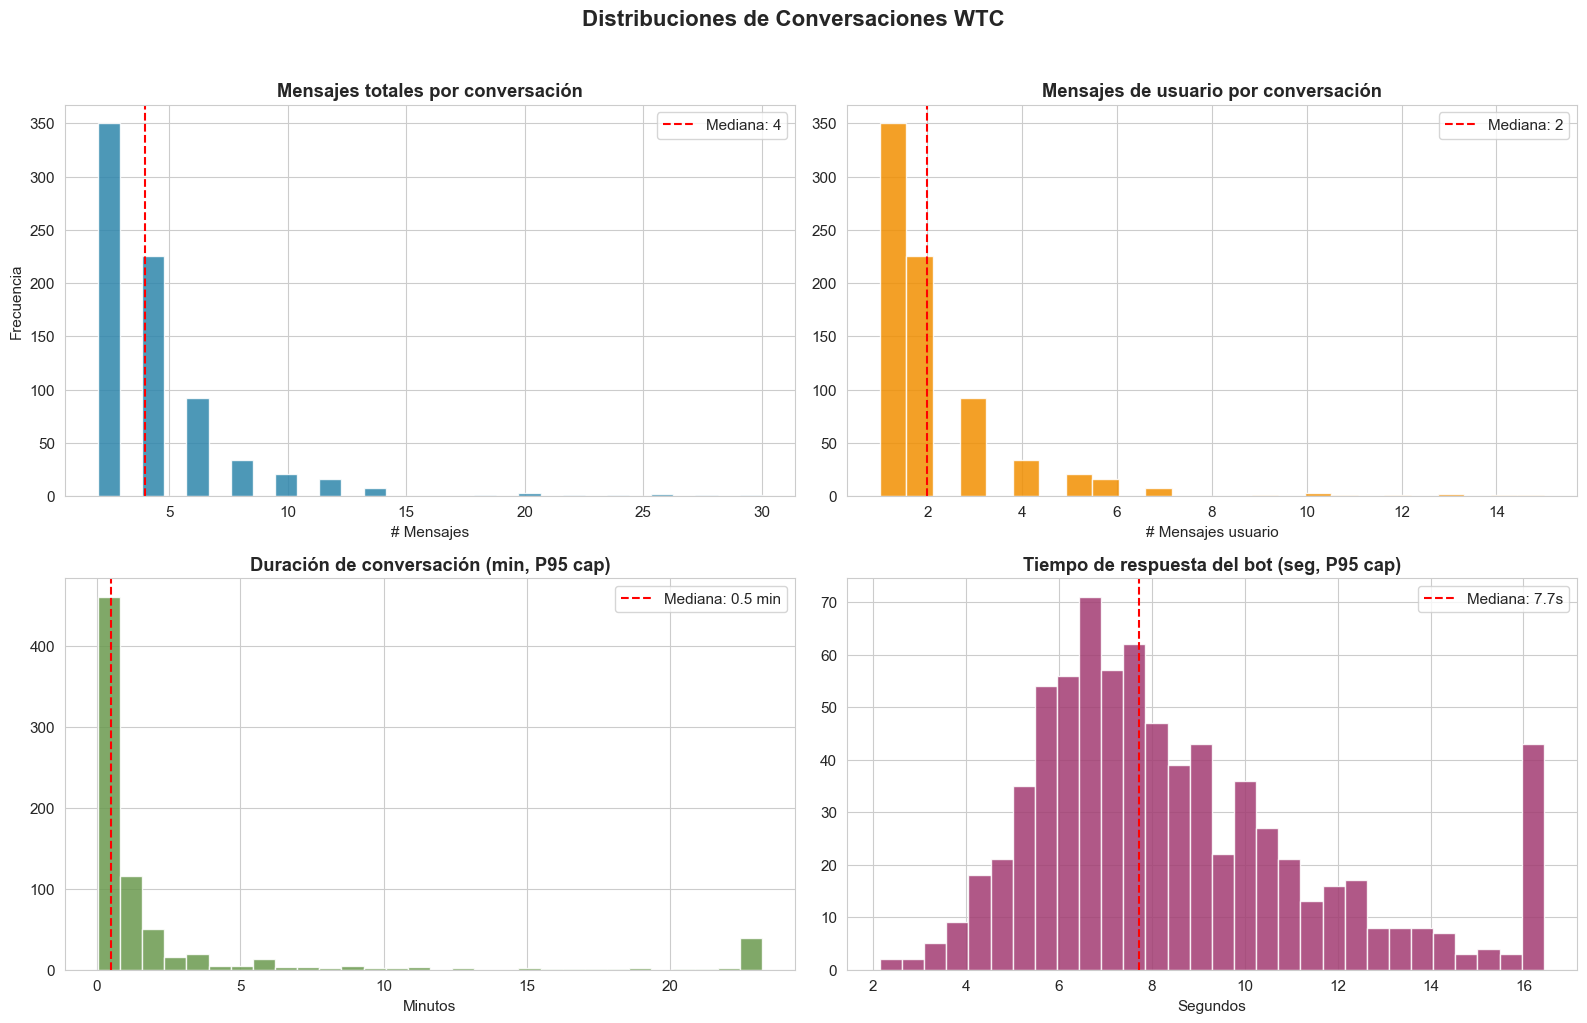

In [8]:
# === 5a. Distribución de mensajes por conversación ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Mensajes totales por conversación
axes[0, 0].hist(df_conv["total_msgs"], bins=30, color="#2E86AB", edgecolor="white", alpha=0.85)
axes[0, 0].axvline(df_conv["total_msgs"].median(), color="red", linestyle="--", label=f"Mediana: {df_conv['total_msgs'].median():.0f}")
axes[0, 0].set_title("Mensajes totales por conversación", fontweight="bold")
axes[0, 0].set_xlabel("# Mensajes")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].legend()

# Mensajes de usuario
axes[0, 1].hist(df_conv["user_msgs"], bins=25, color="#F18F01", edgecolor="white", alpha=0.85)
axes[0, 1].axvline(df_conv["user_msgs"].median(), color="red", linestyle="--", label=f"Mediana: {df_conv['user_msgs'].median():.0f}")
axes[0, 1].set_title("Mensajes de usuario por conversación", fontweight="bold")
axes[0, 1].set_xlabel("# Mensajes usuario")
axes[0, 1].legend()

# Duración de conversación
valid_dur = df_conv[df_conv["duration_min"] > 0]["duration_min"]
axes[1, 0].hist(valid_dur.clip(upper=valid_dur.quantile(0.95)), bins=30, color="#6A994E", edgecolor="white", alpha=0.85)
axes[1, 0].axvline(valid_dur.median(), color="red", linestyle="--", label=f"Mediana: {valid_dur.median():.1f} min")
axes[1, 0].set_title("Duración de conversación (min, P95 cap)", fontweight="bold")
axes[1, 0].set_xlabel("Minutos")
axes[1, 0].legend()

# Tiempo de respuesta del bot
valid_resp = df_conv["avg_response_sec"].dropna()
axes[1, 1].hist(valid_resp.clip(upper=valid_resp.quantile(0.95)), bins=30, color="#A23B72", edgecolor="white", alpha=0.85)
axes[1, 1].axvline(valid_resp.median(), color="red", linestyle="--", label=f"Mediana: {valid_resp.median():.1f}s")
axes[1, 1].set_title("Tiempo de respuesta del bot (seg, P95 cap)", fontweight="bold")
axes[1, 1].set_xlabel("Segundos")
axes[1, 1].legend()

plt.suptitle("Distribuciones de Conversaciones WTC", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

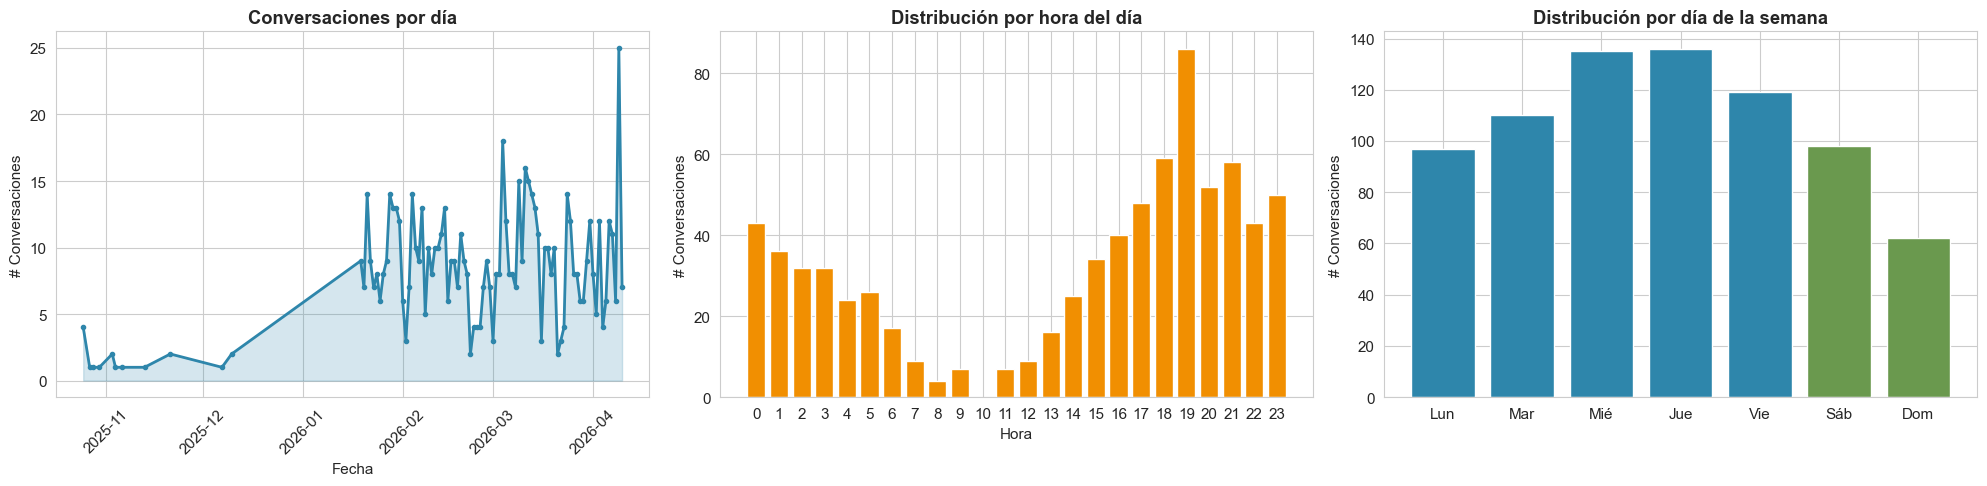

In [9]:
# === 5b. Análisis Temporal ===
df_conv_valid = df_conv[df_conv["first_time"].notna()].copy()
df_conv_valid["date"] = df_conv_valid["first_time"].dt.date
df_conv_valid["hour"] = df_conv_valid["first_time"].dt.hour
df_conv_valid["day_of_week"] = df_conv_valid["first_time"].dt.day_name()
df_conv_valid["week"] = df_conv_valid["first_time"].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Conversaciones por día
daily = df_conv_valid.groupby("date").size()
axes[0].plot(daily.index, daily.values, color="#2E86AB", linewidth=2, marker="o", markersize=3)
axes[0].fill_between(daily.index, daily.values, alpha=0.2, color="#2E86AB")
axes[0].set_title("Conversaciones por día", fontweight="bold")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("# Conversaciones")
axes[0].tick_params(axis="x", rotation=45)

# Distribución por hora del día
hourly = df_conv_valid["hour"].value_counts().sort_index()
axes[1].bar(hourly.index, hourly.values, color="#F18F01", edgecolor="white")
axes[1].set_title("Distribución por hora del día", fontweight="bold")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("# Conversaciones")
axes[1].set_xticks(range(0, 24))

# Distribución por día de la semana
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = df_conv_valid["day_of_week"].value_counts().reindex(day_order).fillna(0)
colors = ["#6A994E" if d in ["Saturday", "Sunday"] else "#2E86AB" for d in day_order]
axes[2].bar(range(7), day_counts.values, color=colors, edgecolor="white")
axes[2].set_title("Distribución por día de la semana", fontweight="bold")
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"])
axes[2].set_ylabel("# Conversaciones")

plt.tight_layout()
plt.show()

C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\3681585718.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="role_label", y="content_length",
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\3681585718.py:23: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\3681585718.py:23: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Guillermo\Downloads\Chatbots\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Guillermo\Downloads\Chatbots\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT F

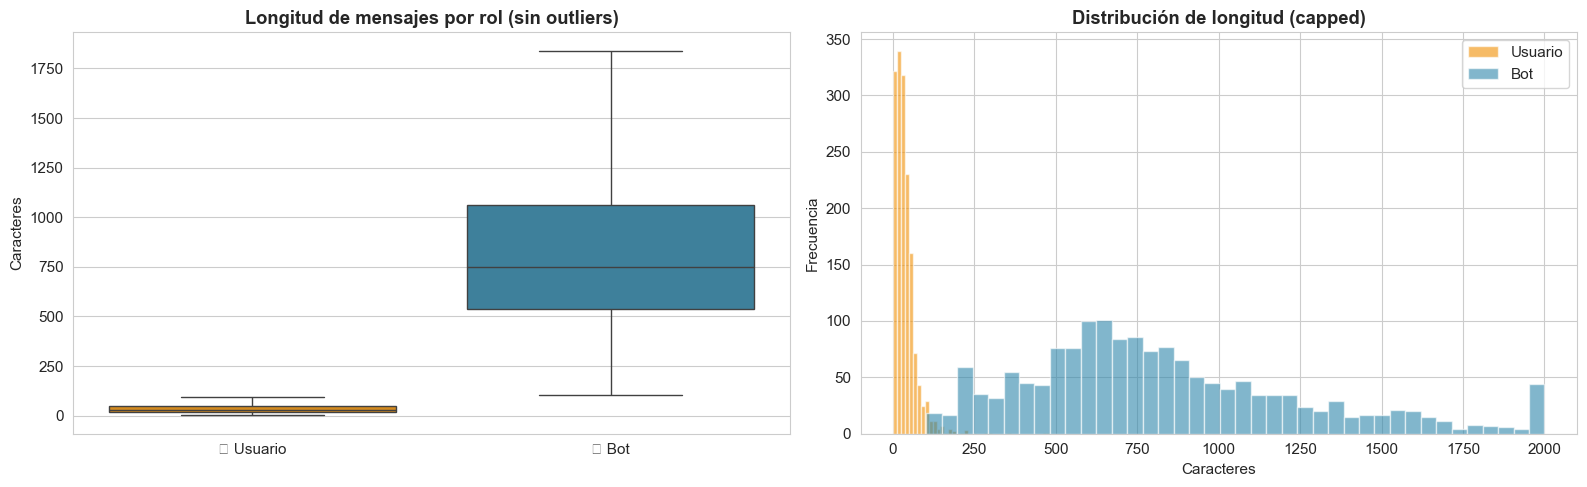

In [10]:
# === 5c. Longitud de mensajes: usuario vs bot ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot comparativo
df_plot = df[df["role"].isin(["user", "bot"])].copy()
df_plot["role_label"] = df_plot["role"].map({"user": "👤 Usuario", "bot": "🤖 Bot"})
sns.boxplot(data=df_plot, x="role_label", y="content_length", 
            palette=["#F18F01", "#2E86AB"], ax=axes[0], showfliers=False)
axes[0].set_title("Longitud de mensajes por rol (sin outliers)", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Caracteres")

# Histograma superpuesto
user_lens = df[df["role"] == "user"]["content_length"].clip(upper=500)
bot_lens = df[df["role"] == "bot"]["content_length"].clip(upper=2000)
axes[1].hist(user_lens, bins=40, alpha=0.6, color="#F18F01", label="Usuario", edgecolor="white")
axes[1].hist(bot_lens, bins=40, alpha=0.6, color="#2E86AB", label="Bot", edgecolor="white")
axes[1].set_title("Distribución de longitud (capped)", fontweight="bold")
axes[1].set_xlabel("Caracteres")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.show()

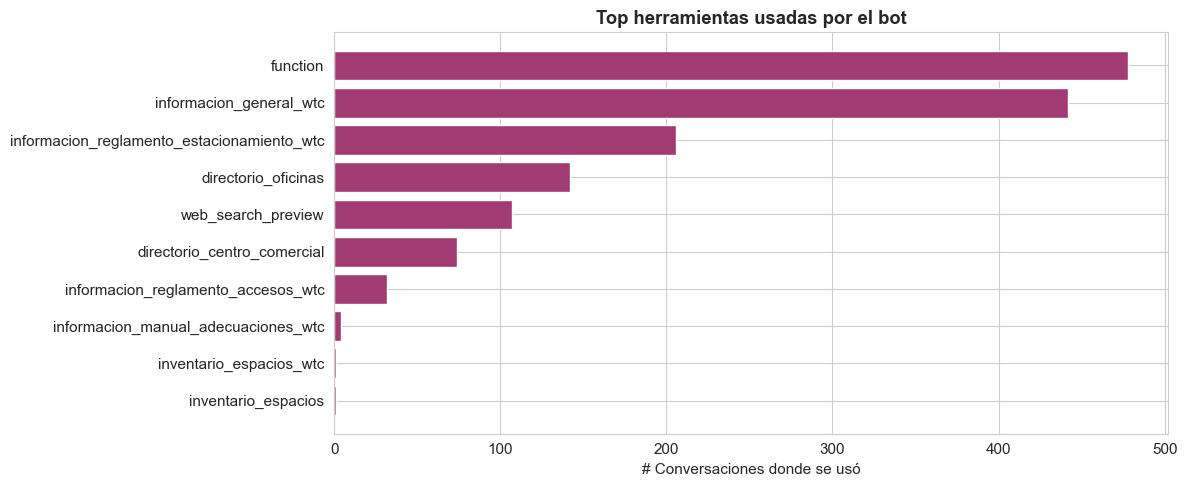


🔧 Total herramientas distintas: 10
📊 Conversaciones con herramientas: 732 / 757 (96.7%)


In [11]:
# === 5d. Herramientas usadas por el bot ===
all_tools = []
for tools_list in df_conv["tools_used"]:
    all_tools.extend(tools_list)

if all_tools:
    tool_counts = Counter(all_tools).most_common(15)
    tools_df = pd.DataFrame(tool_counts, columns=["herramienta", "conversaciones"])
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(tools_df["herramienta"][::-1], tools_df["conversaciones"][::-1], color="#A23B72", edgecolor="white")
    ax.set_title("Top herramientas usadas por el bot", fontweight="bold")
    ax.set_xlabel("# Conversaciones donde se usó")
    plt.tight_layout()
    plt.show()
    
    print(f"\n🔧 Total herramientas distintas: {len(set(all_tools))}")
    print(f"📊 Conversaciones con herramientas: {(df_conv['num_tools'] > 0).sum()} / {len(df_conv)} ({(df_conv['num_tools'] > 0).mean()*100:.1f}%)")
else:
    print("⚠️  No se encontraron herramientas usadas en las conversaciones")

## 6. Análisis de Correlación

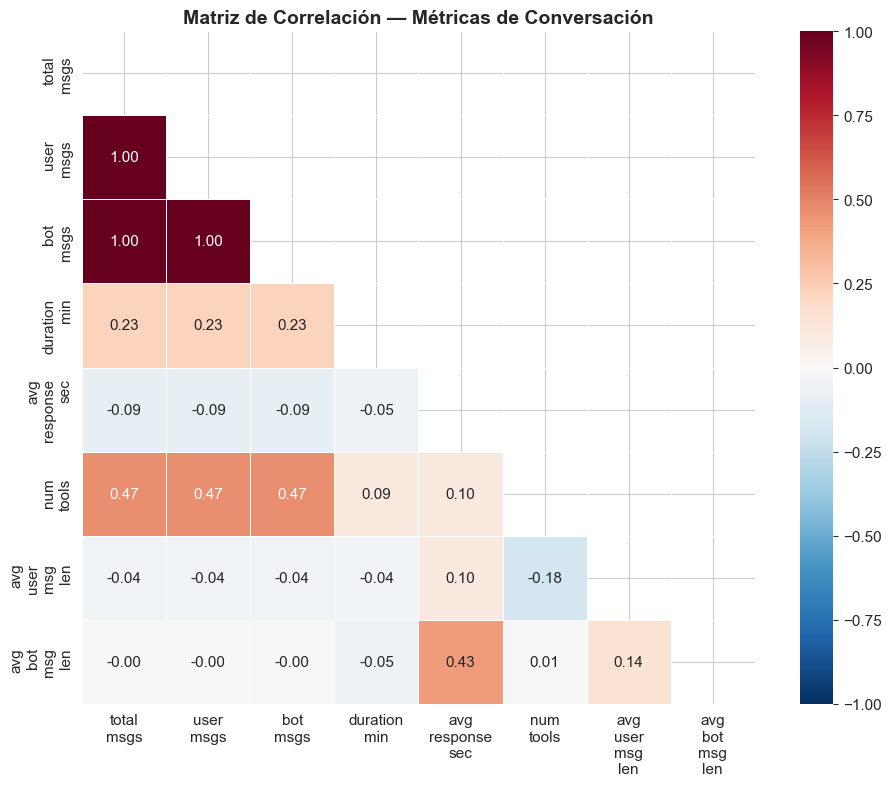


🔗 Correlaciones fuertes (|r| > 0.5):
  total_msgs ↔ user_msgs: r=1.00
  total_msgs ↔ bot_msgs: r=1.00
  user_msgs ↔ bot_msgs: r=1.00


In [12]:
# Correlación entre variables numéricas de conversación
corr_cols = ["total_msgs", "user_msgs", "bot_msgs", "duration_min", 
             "avg_response_sec", "num_tools", "avg_user_msg_len", "avg_bot_msg_len"]
corr_matrix = df_conv[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            xticklabels=[c.replace("_", "\n") for c in corr_cols],
            yticklabels=[c.replace("_", "\n") for c in corr_cols])
ax.set_title("Matriz de Correlación — Métricas de Conversación", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

# Destacar correlaciones fuertes
print("\n🔗 Correlaciones fuertes (|r| > 0.5):")
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {corr_cols[i]} ↔ {corr_cols[j]}: r={r:.2f}")

## 7. Análisis de Patrones de Conversación

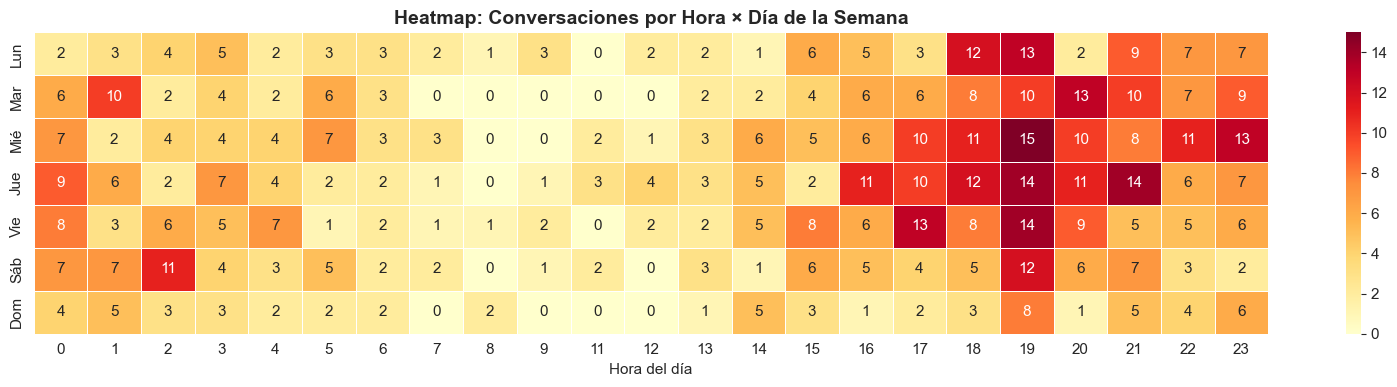

In [13]:
# === 7a. Heatmap hora × día de la semana ===
if len(df_conv_valid) > 0:
    df_conv_valid["dow_num"] = df_conv_valid["first_time"].dt.dayofweek
    heatmap_data = df_conv_valid.groupby(["dow_num", "hour"]).size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(16, 4))
    sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt="d", linewidths=0.5, ax=ax,
                yticklabels=["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"])
    ax.set_title("Heatmap: Conversaciones por Hora × Día de la Semana", fontweight="bold", fontsize=14)
    ax.set_xlabel("Hora del día")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

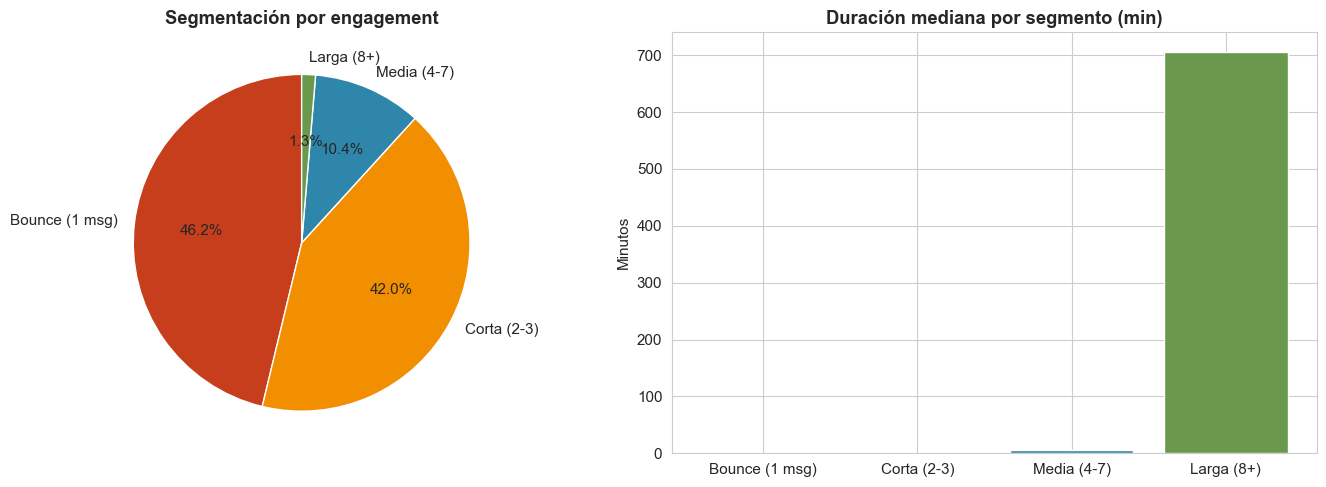


📊 Distribución de engagement:
  Bounce (1 msg): 350 (46.2%)
  Corta (2-3): 318 (42.0%)
  Media (4-7): 79 (10.4%)
  Larga (8+): 10 (1.3%)


In [14]:
# === 7b. Segmentación por engagement ===
df_conv["engagement"] = pd.cut(
    df_conv["user_msgs"],
    bins=[0, 1, 3, 7, 100],
    labels=["Bounce (1 msg)", "Corta (2-3)", "Media (4-7)", "Larga (8+)"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de engagement
eng_counts = df_conv["engagement"].value_counts().reindex(["Bounce (1 msg)", "Corta (2-3)", "Media (4-7)", "Larga (8+)"])
colors_eng = ["#C73E1D", "#F18F01", "#2E86AB", "#6A994E"]
axes[0].pie(eng_counts.values, labels=eng_counts.index, autopct="%1.1f%%", 
            colors=colors_eng, startangle=90, textprops={"fontsize": 11})
axes[0].set_title("Segmentación por engagement", fontweight="bold")

# Duración promedio por segmento
valid_eng = df_conv[df_conv["duration_min"] > 0].groupby("engagement", observed=True)["duration_min"].median()
valid_eng = valid_eng.reindex(["Bounce (1 msg)", "Corta (2-3)", "Media (4-7)", "Larga (8+)"])
axes[1].bar(range(len(valid_eng)), valid_eng.values, color=colors_eng, edgecolor="white")
axes[1].set_xticks(range(len(valid_eng)))
axes[1].set_xticklabels(valid_eng.index)
axes[1].set_title("Duración mediana por segmento (min)", fontweight="bold")
axes[1].set_ylabel("Minutos")

plt.tight_layout()
plt.show()

print(f"\n📊 Distribución de engagement:")
for seg, count in eng_counts.items():
    print(f"  {seg}: {count} ({count/len(df_conv)*100:.1f}%)")

## 8. Resumen Ejecutivo

In [15]:
# === RESUMEN EJECUTIVO AUTOMATIZADO ===
print("=" * 70)
print("📊 RESUMEN EJECUTIVO — EDA WTC CDMX CHATBOT")
print("=" * 70)

print(f"""
🏢 DATASET
  • Sesiones: {len(df_conv):,}
  • Mensajes totales: {len(df):,}
  • Mensajes usuario: {df[df['role']=='user'].shape[0]:,}
  • Mensajes bot: {df[df['role']=='bot'].shape[0]:,}
  • Archivo: {os.path.getsize(DATA_PATH) / 1024 / 1024:.1f} MB
""")

if len(df_conv_valid) > 0:
    print(f"""📅 PERIODO
  • Desde: {df_conv_valid['first_time'].min().strftime('%Y-%m-%d')}
  • Hasta: {df_conv_valid['first_time'].max().strftime('%Y-%m-%d')}
  • Días cubiertos: {(df_conv_valid['first_time'].max() - df_conv_valid['first_time'].min()).days}
  • Promedio diario: {len(df_conv_valid) / max((df_conv_valid['first_time'].max() - df_conv_valid['first_time'].min()).days, 1):.1f} conversaciones/día
""")

print(f"""💬 CONVERSACIONES
  • Mensajes por conversación (mediana): {df_conv['total_msgs'].median():.0f}
  • Preguntas de usuario por sesión (mediana): {df_conv['user_msgs'].median():.0f}
  • Duración mediana: {df_conv[df_conv['duration_min'] > 0]['duration_min'].median():.1f} min
  • Tiempo de respuesta bot (mediana): {df_conv['avg_response_sec'].median():.1f}s
""")

print(f"""📏 LONGITUD DE MENSAJES
  • Pregunta usuario (mediana): {df[df['role']=='user']['content_length'].median():.0f} chars
  • Respuesta bot (mediana): {df[df['role']=='bot']['content_length'].median():.0f} chars
  • Ratio bot/user: {df[df['role']=='bot']['content_length'].median() / max(df[df['role']=='user']['content_length'].median(), 1):.1f}x
""")

eng_counts = df_conv["engagement"].value_counts()
bounce_pct = eng_counts.get("Bounce (1 msg)", 0) / len(df_conv) * 100
print(f"""⚡ ENGAGEMENT
  • Bounce rate (1 sola pregunta): {bounce_pct:.1f}%
  • Conversaciones con herramientas: {(df_conv['num_tools'] > 0).sum()} ({(df_conv['num_tools'] > 0).mean()*100:.1f}%)
""")

# Flags de calidad
print("🚩 FLAGS DE CALIDAD")
ts_coverage = df["timestamp"].notna().sum() / len(df) * 100
print(f"  • Cobertura timestamps: {ts_coverage:.1f}%", "✅" if ts_coverage > 95 else "⚠️")
empty_rate = (empty_user + empty_bot) / len(df) * 100
print(f"  • Mensajes vacíos: {empty_rate:.2f}%", "✅" if empty_rate < 1 else "⚠️")
print(f"  • Balance user/bot: {df[df['role']=='user'].shape[0]}/{df[df['role']=='bot'].shape[0]}", 
      "✅" if abs(df[df['role']=='user'].shape[0] - df[df['role']=='bot'].shape[0]) < 50 else "⚠️")

📊 RESUMEN EJECUTIVO — EDA WTC CDMX CHATBOT

🏢 DATASET
  • Sesiones: 757
  • Mensajes totales: 3,176
  • Mensajes usuario: 1,588
  • Mensajes bot: 1,588
  • Archivo: 27.2 MB

📅 PERIODO
  • Desde: 2025-10-25
  • Hasta: 2026-04-10
  • Días cubiertos: 167
  • Promedio diario: 4.5 conversaciones/día

💬 CONVERSACIONES
  • Mensajes por conversación (mediana): 4
  • Preguntas de usuario por sesión (mediana): 2
  • Duración mediana: 0.5 min
  • Tiempo de respuesta bot (mediana): 7.7s

📏 LONGITUD DE MENSAJES
  • Pregunta usuario (mediana): 30 chars
  • Respuesta bot (mediana): 748 chars
  • Ratio bot/user: 24.9x

⚡ ENGAGEMENT
  • Bounce rate (1 sola pregunta): 46.2%
  • Conversaciones con herramientas: 732 (96.7%)

🚩 FLAGS DE CALIDAD
  • Cobertura timestamps: 100.0% ✅
  • Mensajes vacíos: 0.00% ✅
  • Balance user/bot: 1588/1588 ✅


---
# 🔍 Análisis del Dashboard — Detección por Patrones (Python Regex)
Replica el análisis que realiza `analyzer.py`: brechas de conocimiento, filtraciones de documento, off-topic, longitud, idioma, herramientas.

In [20]:
# === ANÁLISIS POR PATRONES (REGEX) — Igual que analyzer.py ===
import sys, os, importlib
sys.path.insert(0, os.getcwd())
import analyzer
importlib.reload(analyzer)
from analyzer import analyze_chatflow

# Preparar mensajes: mapear 'user'→'userMessage', 'bot'→'apiMessage', 'time'→'createdDate'
all_messages = []
for sess in raw_sessions:
    chat_id = sess.get('sessionId') or sess.get('id') or 'unknown'
    for m in sess.get('messages', []):
        msg = {
            'chatId': chat_id,
            'content': m.get('content', ''),
            'createdDate': m.get('time', ''),
            'usedTools': m.get('usedTools', []),
            'agentReasoning': m.get('agentReasoning', []),
        }
        # Map roles
        role = m.get('role', '')
        if role == 'user':
            msg['role'] = 'userMessage'
        elif role == 'bot':
            msg['role'] = 'apiMessage'
        else:
            msg['role'] = role
        all_messages.append(msg)

print(f"Total mensajes preparados: {len(all_messages)}")
roles = set(m['role'] for m in all_messages)
print(f"Roles: {roles}")

# Ejecutar análisis
pattern_results = analyze_chatflow("WTC-Messages", all_messages)

# Resumen
print(f"\n📊 RESULTADOS DEL ANÁLISIS POR PATRONES")
print(f"{'='*50}")
print(f"Total mensajes:        {pattern_results['total_messages']}")
print(f"Total conversaciones:  {pattern_results['total_conversations']}")
print(f"Msgs usuario:          {pattern_results['user_messages']}")
print(f"Msgs bot:              {pattern_results['bot_messages']}")
print(f"Largo promedio resp:   {pattern_results['avg_response_length']:.0f} chars")
print(f"Msgs/conversación:     {pattern_results['avg_conversation_length']:.1f}")
print(f"\n🔍 PROBLEMAS DETECTADOS:")
print(f"  🔴 Brechas de conocimiento:  {len(pattern_results['knowledge_gaps'])}")
print(f"  📄 Filtraciones documento:   {len(pattern_results['doc_leaks'])}")
print(f"  📏 Problemas de longitud:    {len(pattern_results['length_issues'])}")
print(f"  🌐 Errores de idioma:        {len(pattern_results['language_mismatches'])}")
print(f"  🚫 Off-topic total:          {len(pattern_results['off_topic'])}")
print(f"     ✅ Rechazados (bien):     {pattern_results['off_topic_refused']}")
print(f"     🚫 Respondidos (mal):     {pattern_results['off_topic_answered']}")
print(f"  ⚠️  Convs con problemas:     {pattern_results['conversations_with_issues']}")

Total mensajes preparados: 3176
Roles: {'apiMessage', 'userMessage'}

📊 RESULTADOS DEL ANÁLISIS POR PATRONES
Total mensajes:        3176
Total conversaciones:  753
Msgs usuario:          1588
Msgs bot:              1588
Largo promedio resp:   847 chars
Msgs/conversación:     4.2

🔍 PROBLEMAS DETECTADOS:
  🔴 Brechas de conocimiento:  161
  📄 Filtraciones documento:   4
  📏 Problemas de longitud:    292
  🌐 Errores de idioma:        30
  🚫 Off-topic total:          11
     ✅ Rechazados (bien):     0
     🚫 Respondidos (mal):     11
  ⚠️  Convs con problemas:     172


In [21]:
# === DETALLE: Brechas de conocimiento y Doc Leaks ===
pr = pattern_results

# Knowledge gaps
if pr['knowledge_gaps']:
    print("🔴 BRECHAS DE CONOCIMIENTO — Preguntas sin respuesta")
    print("="*60)
    kg_df = pd.DataFrame(pr['knowledge_gaps'])
    kg_df['date_short'] = kg_df['date'].str[:10]
    print(f"\nTotal: {len(kg_df)} detecciones\n")
    # Top preguntas por frecuencia
    top_kg = kg_df['user_question'].str[:100].value_counts().head(15)
    for q, c in top_kg.items():
        print(f"  [{c}x] {q}")
else:
    print("✅ No se detectaron brechas de conocimiento por patrones")

print()

# Doc leaks
if pr['doc_leaks']:
    print("📄 FILTRACIONES DE DOCUMENTO")
    print("="*60)
    dl_df = pd.DataFrame(pr['doc_leaks'])
    print(f"\nTotal: {len(dl_df)} filtraciones\n")
    for _, row in dl_df.iterrows():
        print(f"  [{row['date'][:10]}] {row['bot_response'][:120]}...")
else:
    print("✅ No se detectaron filtraciones de documento por patrones")

print()

# Length issues
short = [l for l in pr['length_issues'] if l['type'] == 'too_short']
long_ = [l for l in pr['length_issues'] if l['type'] == 'too_long']
print(f"📏 PROBLEMAS DE LONGITUD")
print(f"  Muy cortas (<40 chars): {len(short)}")
print(f"  Muy largas (>1200 chars): {len(long_)}")

# Language
if pr['language_mismatches']:
    print(f"\n🌐 ERRORES DE IDIOMA: {len(pr['language_mismatches'])}")
    for lm in pr['language_mismatches'][:5]:
        print(f"  Usuario ({lm['user_lang']}): {lm['user_msg'][:60]}...")
        print(f"  Bot ({lm['bot_lang']}):     {lm['bot_msg'][:60]}...")
        print()

🔴 BRECHAS DE CONOCIMIENTO — Preguntas sin respuesta

Total: 161 detecciones

  [2x] Si
  [1x] si trabajo en las oficinas de wtc tengo decuentos en algun lado?
  [1x] En su página Pepsi center 
  [1x] Que eventos hay el dia de hoy
  [1x] Actividades 5 de abril
  [1x] Que exposiciónes hay en el mes de abril?
  [1x] Cuanto cuesta subir al observatorio
  [1x] Que hay en el piso 40 y 41?
  [1x] Cuando fue inaugurado el edificio?
  [1x] Que feria está el día de hoy
  [1x] Cuándo es la feria del lueble
  [1x] Que eventos hay hoy?
  [1x] Información de expos y eventos con fechas y costos 
  [1x] Que hay en el piso 29
  [1x] costos de venue

📄 FILTRACIONES DE DOCUMENTO

Total: 4 filtraciones

  [2026-03-10] 🏢 **World Trade Center Mexico City**

El número 55 9000 9000 **no aparece en la lista oficial de teléfonos de servicios ...
  [2026-02-17] 🏢 **World Trade Center Mexico City**
En la información oficial disponible, no se especifica cuál es la bodega con más me...
  [2026-02-12] 🏢 **World Trad

🚫 OFF-TOPIC DETECTADO POR PATRONES: 11 preguntas
   ✅ Rechazadas correctamente: 0
   🚫 Respondidas (debió rechazar): 11



C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\599337046.py:32: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Guillermo\Downloads\Chatbots\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


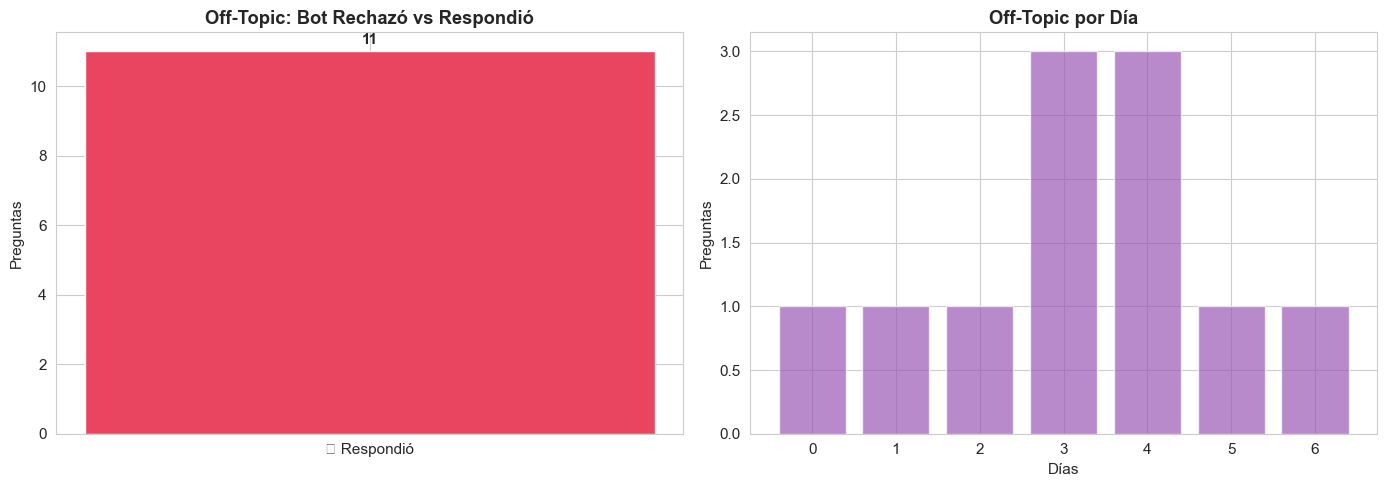


📋 Muestra de preguntas off-topic:
  🚫 Respondió [2026-04-10] 3-10 pm, Requiero pista de baile, DJ, cena buffet, barra libre, servicio de Soni
  🚫 Respondió [2026-03-26] Empresas que son de software,que trabajan con programación, automatización con I
  🚫 Respondió [2026-03-13] Dame una receta para hacer hot cakes.
  🚫 Respondió [2026-03-13] Me acabas de dar una receta de hot cakes.
  🚫 Respondió [2026-03-13] Dame una receta para hacer galletas.
  🚫 Respondió [2026-03-04] Quién es Marcos Añorve 
  🚫 Respondió [2026-03-04] Quién es Isaura garnica
  🚫 Respondió [2026-03-04] Quién es Ana Isabel García Sanciprian 
  🚫 Respondió [2026-02-10] Consultorio para bajar de peso por medio de hipnosis
  🚫 Respondió [2026-01-24] Nos lo han cobrado hoy però la fecha de es del 26/11/25 y la empresa es World tr
  🚫 Respondió [2026-01-21] quién es el contacto para comunicarme va teléfonica


In [22]:
# === OFF-TOPIC: Detección por patrones ===
ot = pr['off_topic']
if ot:
    print(f"🚫 OFF-TOPIC DETECTADO POR PATRONES: {len(ot)} preguntas")
    print(f"   ✅ Rechazadas correctamente: {pr['off_topic_refused']}")
    print(f"   🚫 Respondidas (debió rechazar): {pr['off_topic_answered']}")
    print()
    
    ot_df = pd.DataFrame(ot)
    ot_df['status'] = ot_df['refused'].map({True: '✅ Rechazó', False: '🚫 Respondió'})
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Refused vs Answered
    status_counts = ot_df['status'].value_counts()
    colors_ot = ['#2ecc71' if '✅' in s else '#e94560' for s in status_counts.index]
    axes[0].bar(status_counts.index, status_counts.values, color=colors_ot)
    axes[0].set_title('Off-Topic: Bot Rechazó vs Respondió', fontweight='bold')
    axes[0].set_ylabel('Preguntas')
    for i, v in enumerate(status_counts.values):
        axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')
    
    # Timeline
    ot_df['date_dt'] = pd.to_datetime(ot_df['date'], errors='coerce')
    ot_daily = ot_df.groupby(ot_df['date_dt'].dt.date).size()
    axes[1].bar(range(len(ot_daily)), ot_daily.values, color='#9b59b6', alpha=0.7)
    axes[1].set_title('Off-Topic por Día', fontweight='bold')
    axes[1].set_ylabel('Preguntas')
    axes[1].set_xlabel('Días')
    
    plt.tight_layout()
    plt.show()
    
    # Lista de preguntas
    print("\n📋 Muestra de preguntas off-topic:")
    for _, row in ot_df.head(15).iterrows():
        print(f"  {row['status']} [{row['date'][:10]}] {row['user_question'][:80]}")
else:
    print("✅ No se detectaron preguntas off-topic por patrones")

---
# 🤖 Análisis IA (GPT) — Resultados Agregados
Carga los resultados del análisis con inteligencia artificial: intenciones, sentimiento, calidad, temas, off-topic, filtraciones.

In [43]:
# === EJECUTAR ANÁLISIS IA (GPT-5.2) — Prompt v2 con contexto de agente ===
import json, shutil, time, importlib
from message_loader import build_conversations
import ai_analyzer
importlib.reload(ai_analyzer)  # Force reload to pick up SYSTEM_PROMPT changes
from ai_analyzer import analyze_conversations_ai, aggregate_ai_results, CACHE_DIR

# 1) Limpiar cache para forzar re-análisis
if os.path.exists(CACHE_DIR):
    n_cached = len([f for f in os.listdir(CACHE_DIR) if f.endswith('.json')])
    print(f"🗑️  Limpiando {n_cached} archivos de cache...")
    shutil.rmtree(CACHE_DIR)
    os.makedirs(CACHE_DIR, exist_ok=True)
    print("   Cache limpiado ✅")
else:
    print("ℹ️  No hay cache previo")

# 2) Construir conversaciones
conversations = build_conversations(raw_sessions)
print(f"\n📊 {len(conversations)} conversaciones a analizar con GPT-5.2")

# 3) Ejecutar análisis IA con progress
t0 = time.time()
def show_progress(done, total):
    elapsed = time.time() - t0
    rate = done / elapsed if elapsed > 0 else 0
    eta = (total - done) / rate if rate > 0 else 0
    print(f"  ⏳ {done}/{total} ({done/total*100:.0f}%) — {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining", flush=True)

print("🤖 Iniciando análisis IA (prompt v2 alineado a rutas del agente)...")
ai_results_raw = analyze_conversations_ai(conversations, batch_size=15, on_progress=show_progress)
elapsed = time.time() - t0
print(f"\n✅ Análisis completado en {elapsed:.0f}s")

# 4) Agregar resultados
ai = aggregate_ai_results(conversations, ai_results_raw)
ai['filename'] = 'WTC-Messages.json'

# 5) Guardar resultados
DATA_DIR = os.path.dirname(DATA_PATH)
results_dir = os.path.join(DATA_DIR, '.ai_results')
os.makedirs(results_dir, exist_ok=True)
results_path = os.path.join(results_dir, 'WTC-Messages_ai.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(ai, f, ensure_ascii=False, indent=2)
print(f"💾 Resultados guardados en {results_path}")

# 6) Resumen rápido
routes = ai.get('routes', ai.get('intents', {}))
print(f"\n📈 RESUMEN RÁPIDO:")
print(f"   Calidad promedio:  {ai['avg_quality_score']:.2f}/5")
print(f"   Confianza prom:    {ai.get('avg_confidence', 'N/A')}")
print(f"   Resueltos:         {ai['handled']} ({ai['handled_pct']}%)")
print(f"   Problemas:         {sum(ai['issues'].values())}")
print(f"   'otro':            {routes.get('otro', 0)} ({routes.get('otro', 0)/len(conversations)*100:.1f}%)")

🗑️  Limpiando 757 archivos de cache...
   Cache limpiado ✅

📊 757 conversaciones a analizar con GPT-5.2
🤖 Iniciando análisis IA (prompt v2 alineado a rutas del agente)...
  ⏳ 15/757 (2%) — 32s elapsed, ~1583s remaining
  ⏳ 30/757 (4%) — 73s elapsed, ~1760s remaining
  ⏳ 45/757 (6%) — 112s elapsed, ~1766s remaining
  ⏳ 60/757 (8%) — 115s elapsed, ~1341s remaining
  ⏳ 75/757 (10%) — 150s elapsed, ~1367s remaining
  ⏳ 90/757 (12%) — 181s elapsed, ~1342s remaining
  ⏳ 105/757 (14%) — 217s elapsed, ~1350s remaining
  ⏳ 120/757 (16%) — 252s elapsed, ~1339s remaining
  ⏳ 135/757 (18%) — 289s elapsed, ~1334s remaining
  ⏳ 150/757 (20%) — 330s elapsed, ~1336s remaining
  ⏳ 165/757 (22%) — 365s elapsed, ~1311s remaining
  ⏳ 180/757 (24%) — 397s elapsed, ~1273s remaining
  ⏳ 195/757 (26%) — 434s elapsed, ~1250s remaining
  ⏳ 210/757 (28%) — 468s elapsed, ~1219s remaining
  ⏳ 225/757 (30%) — 507s elapsed, ~1199s remaining
  ⏳ 240/757 (32%) — 550s elapsed, ~1185s remaining
  ⏳ 255/757 (34%) — 555s 

In [45]:
# === RESUMEN RESULTADOS IA + VISUALIZACIONES ===
# Labels alineados a las 8 rutas del agente WTC
ROUTE_LABELS = {
    'info_general': '🏢 Info General', 'servicios_profesionales': '👔 Servicios Prof.',
    'centro_comercial': '🛍️ Centro Comercial', 'reglamento_acceso': '📋 Reglamento Acceso',
    'propietarios': '🔧 Propietarios', 'estacionamiento': '🅿️ Estacionamiento',
    'espacios_disponibles': '🏗️ Espacios Disp.', 'off_topic': '🚫 Off-Topic',
    'saludo': '👋 Saludo', 'otro': '❓ Otro',
    # backward compat from old analysis
    'informacion_general': '🏢 Info General', 'directorio': '👔 Directorio',
    'oficinas_renta': '🏗️ Oficinas/Renta', 'eventos': '🎵 Eventos',
    'restaurantes': '🍽️ Restaurantes', 'quejas': '😤 Quejas',
}
INTENT_LABELS = ROUTE_LABELS  # backward compat
ISSUE_LABELS = {
    'no_info': '❌ Sin información', 'doc_leak': '📄 Filtración doc',
    'too_generic': '😶 Genérica', 'too_short': '📏 Muy corta',
    'too_long': '📏 Muy larga', 'wrong_redirect': '↩️ Redirección',
    'off_topic_answered': '🚫 OT respondido', 'off_topic_refused': '✅ OT rechazado',
    'language_mismatch': '🌐 Idioma',
}
OT_CAT_LABELS = {
    'math': '🔢 Matemáticas', 'coding': '💻 Programación',
    'recipes': '🍳 Recetas', 'creative_writing': '✍️ Escritura',
    'trivia': '🧠 Cultura general', 'health': '💊 Salud',
    'entertainment': '🎬 Entretenimiento', 'sports': '⚽ Deportes',
    'ai_meta': '🤖 Sobre IA', 'personal': '👤 Personal', 'other': '❓ Otro',
    'matematicas': '🔢 Matemáticas', 'programacion': '💻 Programación',
    'recetas': '🍳 Recetas', 'cultura_general': '🧠 Cultura gral',
    'salud': '💊 Salud', 'salud_personal': '💊 Salud', 'deportes': '⚽ Deportes',
    'traduccion': '🌐 Traducción', 'entretenimiento': '🎬 Entretenimiento',
}
RQ_LABELS = {
    'specific': ('✅ Específica', '#2ecc71'), 'generic': ('😶 Genérica', '#f39c12'),
    'incorrect': ('❌ Incorrecta', '#e94560'), 'no_answer': ('🚫 Sin respuesta', '#e67e22'),
}

print("🤖 RESULTADOS DEL ANÁLISIS IA (GPT-5.2 — Prompt con contexto de agente)")
print("="*60)
print(f"Conversaciones:  {ai['total_conversations']}")
print(f"Calidad prom:    {ai['avg_quality_score']:.2f}/5")
print(f"Confianza prom:  {ai.get('avg_confidence', 'N/A')}")
print(f"Resueltos:       {ai['handled']} ({ai['handled_pct']}%)")
print(f"No resueltos:    {ai['unhandled']}")

# Use 'routes' if available, fallback to 'intents'
routes = ai.get('routes', ai.get('intents', {}))
print(f"\n🗺️  RUTAS DEL AGENTE (clasificación alineada al chatbot):")
for route, count in sorted(routes.items(), key=lambda x: -x[1]):
    pct = count / ai['total_conversations'] * 100
    label = ROUTE_LABELS.get(route, route)
    bar = '█' * max(1, int(pct / 2))
    print(f"  {label:<28} {bar} {count} ({pct:.1f}%)")

# Sub-intents if available
sub_intents = ai.get('sub_intents', {})
if sub_intents:
    print(f"\n🔍 SUB-INTENCIONES (top 15):")
    for si, count in list(sorted(sub_intents.items(), key=lambda x: -x[1]))[:15]:
        print(f"  {si:<40} {count}")

print(f"\n📊 Distribución de calidad:")
for score in sorted(ai['quality_distribution'].keys()):
    count = ai['quality_distribution'][score]
    bar = '█' * (count // 5)
    print(f"  ⭐ {score}: {bar} {count}")

total_issues = sum(ai['issues'].values())
print(f"\n⚠️  Problemas IA: {total_issues}")
for issue, count in sorted(ai['issues'].items(), key=lambda x: -x[1]):
    print(f"  {ISSUE_LABELS.get(issue, issue)}: {count}")

# Check "otro" percentage
otro_count = routes.get('otro', 0)
otro_pct = otro_count / ai['total_conversations'] * 100
print(f"\n{'✅' if otro_pct < 5 else '⚠️'} 'otro' = {otro_pct:.1f}% ({'OK' if otro_pct < 5 else 'sigue alto — revisar prompt'})")

🤖 RESULTADOS DEL ANÁLISIS IA (GPT-5.2 — Prompt con contexto de agente)
Conversaciones:  757
Calidad prom:    2.88/5
Confianza prom:  0.703
Resueltos:       369 (48.7%)
No resueltos:    388

🗺️  RUTAS DEL AGENTE (clasificación alineada al chatbot):
  🏢 Info General               █████████████ 210 (27.7%)
  🅿️ Estacionamiento           ███████████ 177 (23.4%)
  ❓ Otro                       ████████ 131 (17.3%)
  👔 Servicios Prof.            ███████ 111 (14.7%)
  🛍️ Centro Comercial          ███ 54 (7.1%)
  🏗️ Espacios Disp.            ███ 48 (6.3%)
  📋 Reglamento Acceso          █ 18 (2.4%)
  🚫 Off-Topic                  █ 4 (0.5%)
  🔧 Propietarios               █ 3 (0.4%)
  👋 Saludo                     █ 1 (0.1%)

🔍 SUB-INTENCIONES (top 15):
  estacionamiento/tarifas                  85
  info_general/eventos                     49
  info_general/salones                     46
  info_general/servicios                   42
  servicios_profesionales/buscar_empresa   38
  servicios_profesi

C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2920584937.py:52: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2920584937.py:52: UserWarning: Glyph 127359 (\N{NEGATIVE SQUARED LATIN CAPITAL LETTER P}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2920584937.py:52: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2920584937.py:52: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2920584937.py:52: UserWarning: Glyph 128084 (\N{NECKTIE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2920584937.py:52: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) miss

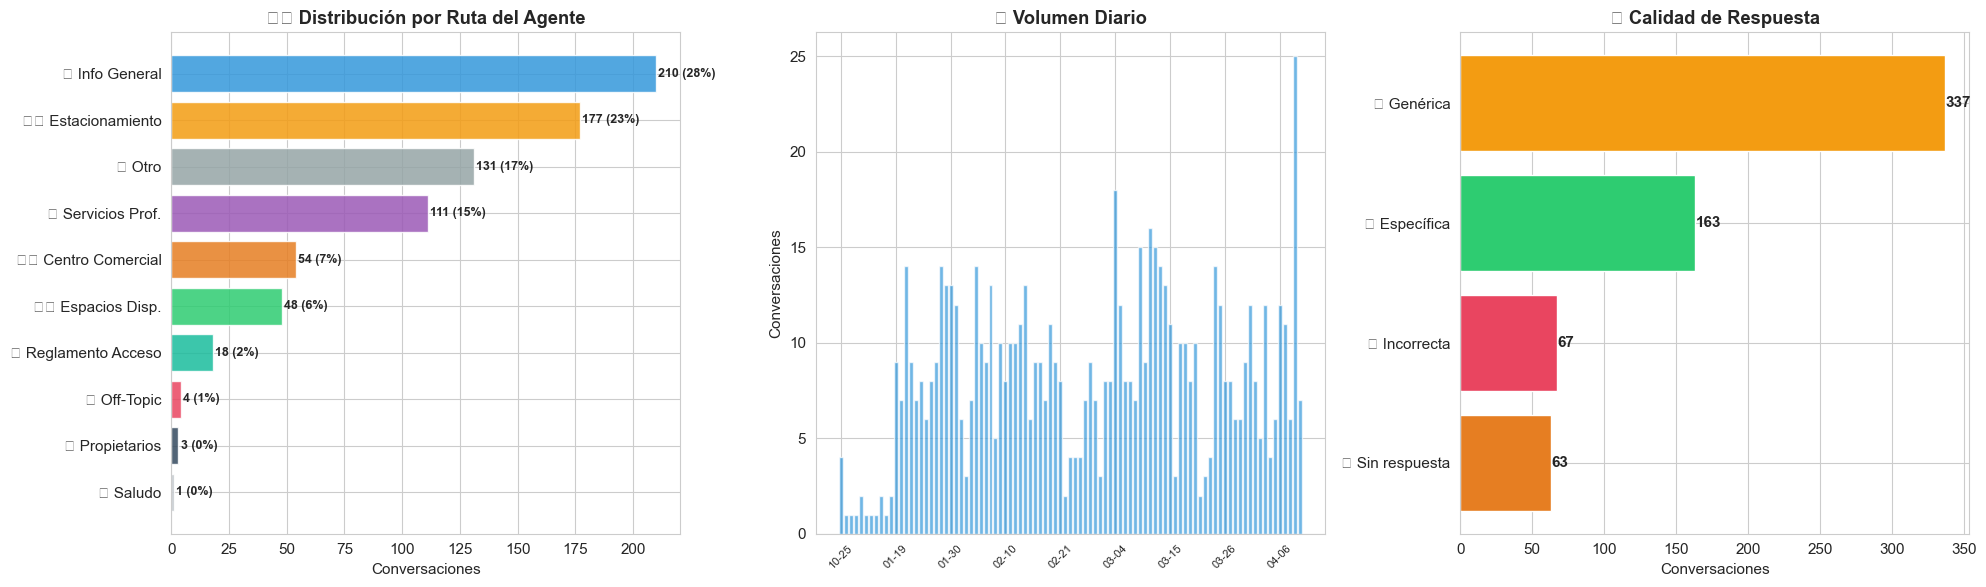

In [46]:
# === DISTRIBUCIÓN DE RUTAS + VOLUMEN DIARIO + CALIDAD ===
routes = ai.get('routes', ai.get('intents', {}))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Route distribution (treemap-style horizontal bar)
route_data = sorted(routes.items(), key=lambda x: -x[1])
r_labels = [ROUTE_LABELS.get(k, k) for k, _ in route_data]
r_values = [v for _, v in route_data]
r_pcts = [v / ai['total_conversations'] * 100 for v in r_values]
# Color by route type
route_colors = {
    'info_general': '#3498db', 'servicios_profesionales': '#9b59b6',
    'centro_comercial': '#e67e22', 'reglamento_acceso': '#1abc9c',
    'propietarios': '#34495e', 'estacionamiento': '#f39c12',
    'espacios_disponibles': '#2ecc71', 'off_topic': '#e94560',
    'saludo': '#bdc3c7', 'otro': '#95a5a6',
}
r_colors = [route_colors.get(k, '#888') for k, _ in route_data]
bars = axes[0].barh(r_labels, r_values, color=r_colors, alpha=0.85)
for bar, val, pct in zip(bars, r_values, r_pcts):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val} ({pct:.0f}%)', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('🗺️ Distribución por Ruta del Agente', fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('Conversaciones')

# 2) Volumen diario
daily_ai = sorted(ai['daily_volume'].items())
dates_ai = [d for d, _ in daily_ai]
counts_ai = [c for _, c in daily_ai]
axes[1].bar(range(len(dates_ai)), counts_ai, color='#3498db', alpha=0.7)
axes[1].set_title('📈 Volumen Diario', fontweight='bold')
axes[1].set_ylabel('Conversaciones')
tick_step = max(1, len(dates_ai) // 8)
axes[1].set_xticks(range(0, len(dates_ai), tick_step))
axes[1].set_xticklabels([dates_ai[i][5:] for i in range(0, len(dates_ai), tick_step)], rotation=45, fontsize=8)

# 3) Response Quality
rq = ai['response_quality']
rq_labels = [RQ_LABELS.get(k, (k, '#888'))[0] for k in rq]
rq_values = list(rq.values())
rq_colors = [RQ_LABELS.get(k, (k, '#888'))[1] for k in rq]
bars = axes[2].barh(rq_labels, rq_values, color=rq_colors)
for bar, val in zip(bars, rq_values):
    axes[2].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val),
                 va='center', fontweight='bold')
axes[2].set_title('🎯 Calidad de Respuesta', fontweight='bold')
axes[2].set_xlabel('Conversaciones')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\3077742136.py:51: UserWarning: Glyph 127359 (\N{NEGATIVE SQUARED LATIN CAPITAL LETTER P}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\3077742136.py:51: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\3077742136.py:51: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\3077742136.py:51: UserWarning: Glyph 128084 (\N{NECKTIE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\3077742136.py:51: UserWarning: Glyph 127959 (\N{BUILDING CONSTRUCTION}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\3077742136.py:51: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing fr

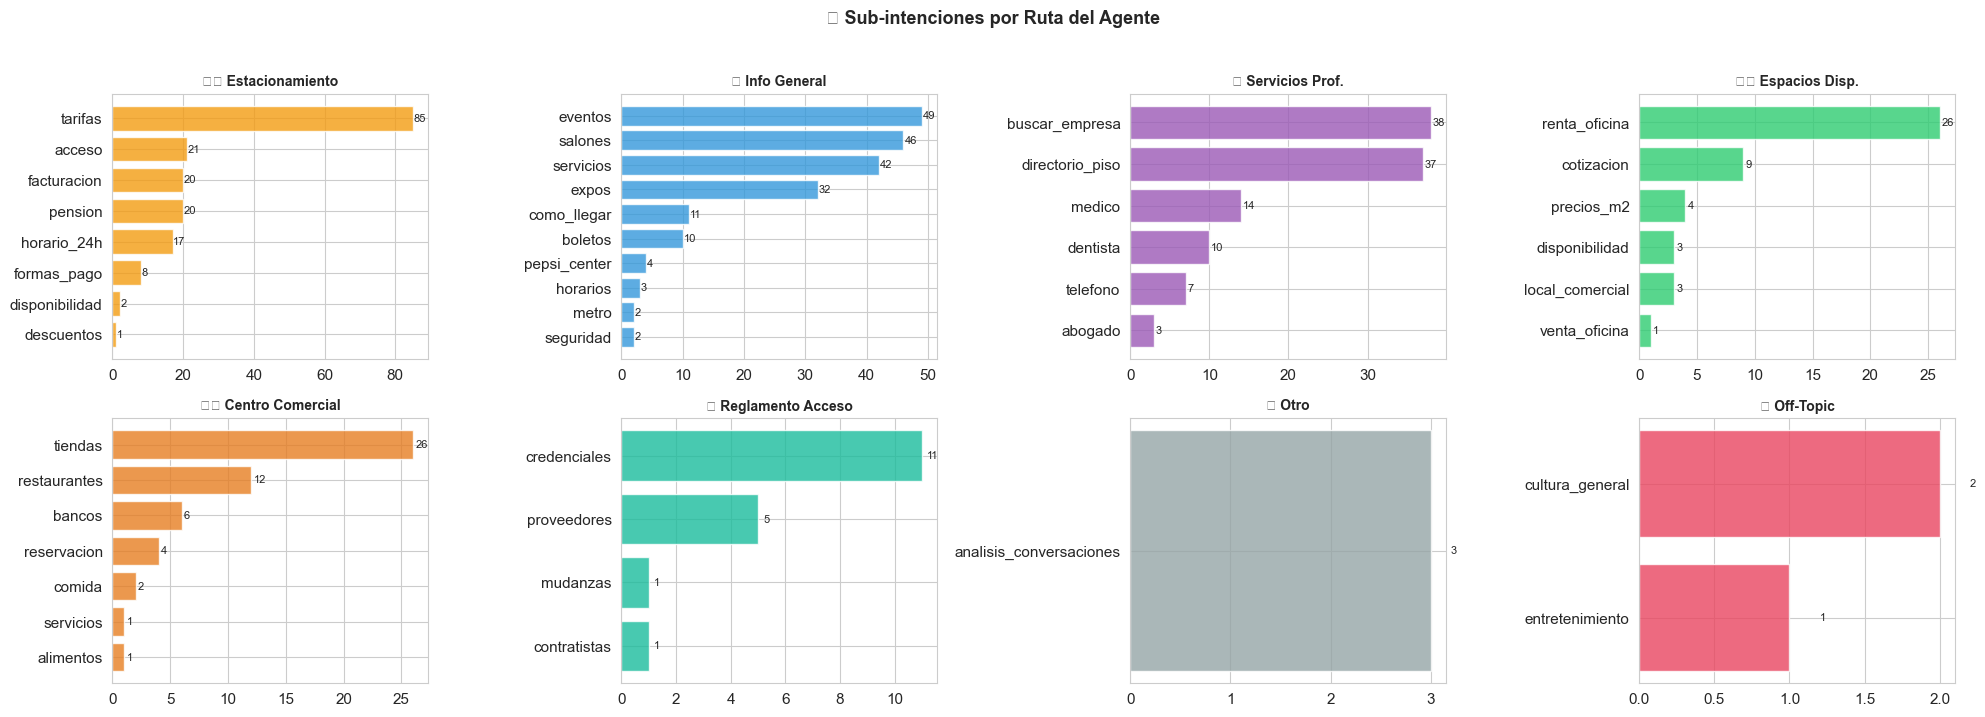

In [47]:
# === SUB-INTENCIONES POR RUTA DEL AGENTE ===
sub_intents = ai.get('sub_intents', {})
routes = ai.get('routes', ai.get('intents', {}))

if sub_intents:
    # Group sub-intents by route
    route_groups = {}
    for si_key, count in sorted(sub_intents.items(), key=lambda x: -x[1]):
        parts = si_key.split('/', 1)
        route = parts[0] if len(parts) > 1 else 'otro'
        sub = parts[1] if len(parts) > 1 else si_key
        route_groups.setdefault(route, []).append((sub, count))

    # One subplot per active route
    active_routes = [(r, items) for r, items in route_groups.items() if len(items) >= 1]
    n_routes = min(len(active_routes), 8)
    if n_routes > 0:
        cols = min(4, n_routes)
        rows = (n_routes + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
        if n_routes == 1:
            axes = [axes]
        else:
            axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

        route_colors_map = {
            'info_general': '#3498db', 'servicios_profesionales': '#9b59b6',
            'centro_comercial': '#e67e22', 'reglamento_acceso': '#1abc9c',
            'propietarios': '#34495e', 'estacionamiento': '#f39c12',
            'espacios_disponibles': '#2ecc71', 'off_topic': '#e94560',
            'saludo': '#bdc3c7', 'otro': '#95a5a6',
        }

        for idx, (route, items) in enumerate(active_routes[:n_routes]):
            ax = axes[idx]
            labels = [s for s, _ in items[:10]]
            values = [c for _, c in items[:10]]
            color = route_colors_map.get(route, '#888')
            ax.barh(labels, values, color=color, alpha=0.8)
            ax.set_title(f'{ROUTE_LABELS.get(route, route)}', fontweight='bold', fontsize=10)
            ax.invert_yaxis()
            for bar, val in zip(ax.patches, values):
                ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                        str(val), va='center', fontsize=8)

        # Hide empty axes
        for idx in range(n_routes, len(axes)):
            axes[idx].set_visible(False)

        plt.suptitle('🔍 Sub-intenciones por Ruta del Agente', fontweight='bold', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("ℹ️  Sin datos de sub-intenciones (ejecuta el análisis con el prompt v2)")

C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\60328305.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\60328305.py:32: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()


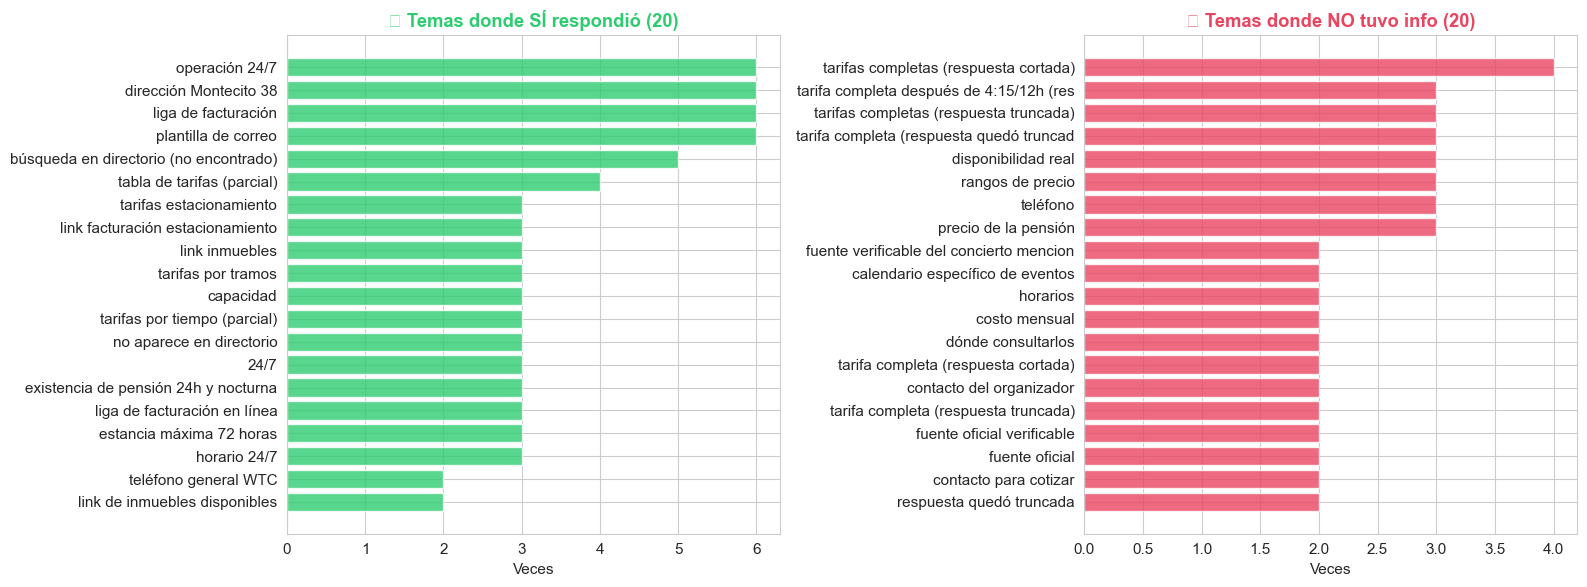


🔴 BRECHAS DE CONOCIMIENTO (IA) — 20 preguntas sin respuesta:
  [2x] Tabla completa de tarifas (4:15 a 12h y máximo diario)
  [2x] Teléfonos/canales completos de Administración del Estacionamiento
  [1x] ¿Dónde comprar/consultar boletos y precios por concierto específico?
  [1x] Contacto (tel/correo) de Hábitat Real State si opera en el WTC
  [1x] Disponibilidad y costo estimado por salón/paquete para 235 personas
  [1x] ¿Existe guardarropa/paquetería en Pepsi Center para cascos? ¿Costo y horario?
  [1x] Registro de consultorio/oficina 20B en piso 27
  [1x] Entrada exacta de 'Centro Aesthetic México' en directorio
  [1x] ¿Aplica promo $120 para el concierto específico y en qué accesos/horarios?
  [1x] Tarifa fija/promoción vigente para Sara Landry 9-abr-2026 en Pepsi Center
  [1x] Contacto correcto para cotizar salas/oficinas para capacitación dentro del WTC
  [1x] URL correcta y completa del portal de facturación (sin duplicación)
  [1x] Teléfono/correo completo de soporte de facturac

In [48]:
# === TEMAS: Handled vs No Info + Brechas de Conocimiento (IA) ===
topics_handled = list(ai['topics_handled'].items())[:20]
topics_no_info = list(ai['topics_no_info'].items())[:20]
knowledge_gaps = list(ai['knowledge_gaps'].items())[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Topics handled
if topics_handled:
    th_labels = [t[:40] for t, _ in topics_handled]
    th_values = [c for _, c in topics_handled]
    axes[0].barh(th_labels, th_values, color='#2ecc71', alpha=0.8)
    axes[0].set_title(f'✅ Temas donde SÍ respondió ({len(topics_handled)})', fontweight='bold', color='#2ecc71')
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Veces')
else:
    axes[0].text(0.5, 0.5, 'Sin datos', ha='center', va='center', fontsize=14, color='gray')
    axes[0].set_title('✅ Temas donde SÍ respondió', fontweight='bold')

# Topics no info
if topics_no_info:
    tni_labels = [t[:40] for t, _ in topics_no_info]
    tni_values = [c for _, c in topics_no_info]
    axes[1].barh(tni_labels, tni_values, color='#e94560', alpha=0.8)
    axes[1].set_title(f'❌ Temas donde NO tuvo info ({len(topics_no_info)})', fontweight='bold', color='#e94560')
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Veces')
else:
    axes[1].text(0.5, 0.5, '¡Excelente! Sin datos', ha='center', va='center', fontsize=14, color='#2ecc71')
    axes[1].set_title('❌ Temas donde NO tuvo info', fontweight='bold')

plt.tight_layout()
plt.show()

# Knowledge gaps table
if knowledge_gaps:
    print(f"\n🔴 BRECHAS DE CONOCIMIENTO (IA) — {len(knowledge_gaps)} preguntas sin respuesta:")
    for q, count in knowledge_gaps:
        print(f"  [{count}x] {q}")

# Doc leaks
doc_leaks = ai['doc_leaks']
if doc_leaks:
    print(f"\n📄 FILTRACIONES DE DOCUMENTO (IA) — {len(doc_leaks)} detecciones:")
    for dl in doc_leaks[:10]:
        print(f"  [{dl.get('date','')[:10]}] \"{dl['text']}\"  (sesión: {dl.get('session_id','-')[:20]})")

C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2103180280.py:46: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2103180280.py:46: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2103180280.py:46: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2103180280.py:46: UserWarning: Glyph 128138 (\N{PILL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2103180280.py:46: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\2103180280.py:46: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Gui

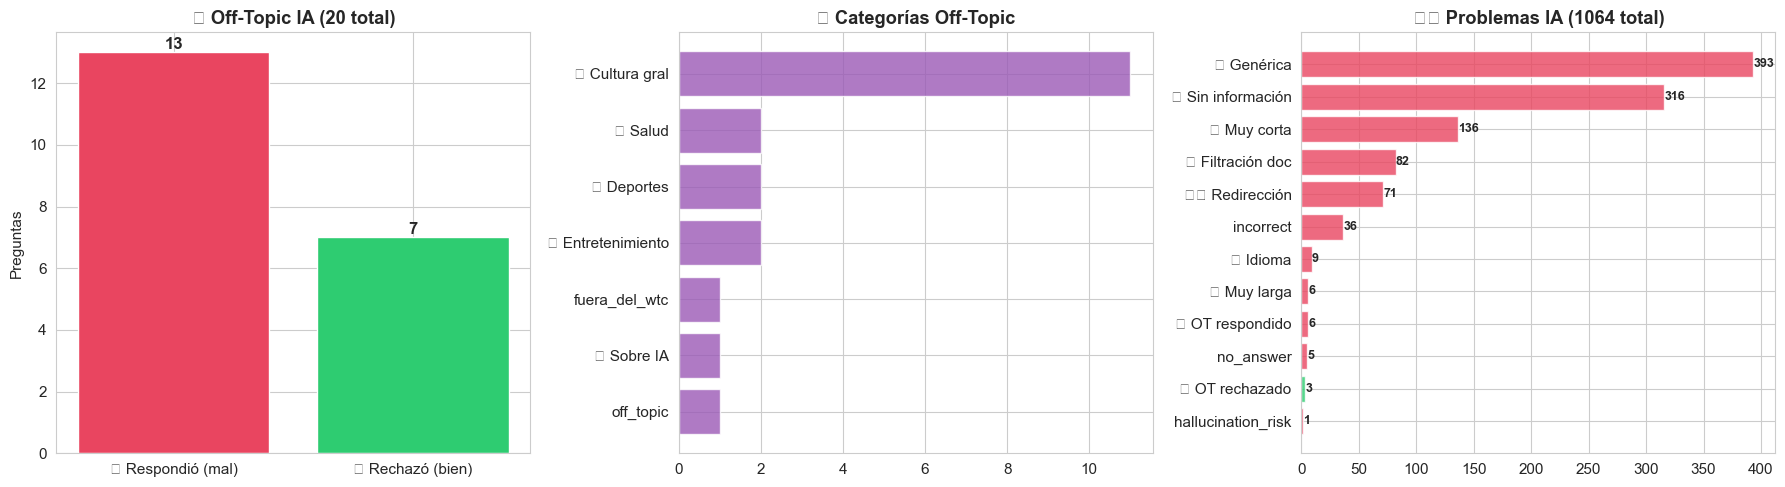


🚫 PREGUNTAS OFF-TOPIC (IA) — 20 detecciones:
  🚫 Respondió [💊 Salud] Me duele una muela
  ✅ Rechazó [⚽ Deportes] Para el partido de america vs cruzazul si tendrán servicio de transporte?
  ✅ Rechazó [🧠 Cultura gral] Donde veo vacantes? / quiero revisar vacantes laborales
  ✅ Rechazó [🧠 Cultura gral] Quiero alquilar un apartamento.
  🚫 Respondió [🧠 Cultura gral] Hace vuelos de avión aquí?
  🚫 Respondió [🧠 Cultura gral] Si buscar (sucursales Afasa cerca del WTC / con Beway)
  ✅ Rechazó [fuera_del_wtc] Hola quisiera reservar para un evento en la plaza de toros
  🚫 Respondió [🧠 Cultura gral] Oficina del gobierno de Morelos
  🚫 Respondió [🧠 Cultura gral] Qué es sofipo
  🚫 Respondió [🤖 Sobre IA] Visión avand
  🚫 Respondió [off_topic] Lo revisaré y te daré recomendaciones para mejorarlo antes de que lo envíes. (re
  🚫 Respondió [🧠 Cultura gral] Quienes son tu competencia directa e indirecta?
  🚫 Respondió [🧠 Cultura gral] Cuando se creó esta página web
  ✅ Rechazó [🎬 Entretenimiento] ¿Hay al

In [49]:
# === OFF-TOPIC IA + Problemas Detectados ===
ot_questions = ai['off_topic_questions']
ot_cats = ai['off_topic_categories']
ot_answered_ai = ai['off_topic_answered']
ot_refused_ai = ai['off_topic_refused']
issues = ai['issues']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Off-topic stats
ot_stats = {'🚫 Respondió (mal)': ot_answered_ai, '✅ Rechazó (bien)': ot_refused_ai}
colors_ots = ['#e94560', '#2ecc71']
bars = axes[0].bar(ot_stats.keys(), ot_stats.values(), color=colors_ots)
for bar, val in zip(bars, ot_stats.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val),
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_title(f'🚫 Off-Topic IA ({len(ot_questions)} total)', fontweight='bold')
axes[0].set_ylabel('Preguntas')

# 2) Off-topic categories
if ot_cats:
    cat_data = sorted(ot_cats.items(), key=lambda x: -x[1])
    cat_labels = [OT_CAT_LABELS.get(k, k) for k, _ in cat_data]
    cat_values = [v for _, v in cat_data]
    axes[1].barh(cat_labels, cat_values, color='#9b59b6', alpha=0.8)
    axes[1].set_title('📂 Categorías Off-Topic', fontweight='bold')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'Sin off-topic', ha='center', va='center', fontsize=14, color='#2ecc71')
    axes[1].set_title('📂 Categorías Off-Topic', fontweight='bold')

# 3) Issues breakdown
if issues:
    iss_data = sorted(issues.items(), key=lambda x: -x[1])
    iss_labels = [ISSUE_LABELS.get(k, k) for k, _ in iss_data]
    iss_values = [v for _, v in iss_data]
    iss_colors = ['#2ecc71' if 'refused' in k else '#e94560' for k, _ in iss_data]
    axes[2].barh(iss_labels, iss_values, color=iss_colors, alpha=0.8)
    for i, (bar_val, label) in enumerate(zip(iss_values, iss_labels)):
        axes[2].text(bar_val + 0.3, i, str(bar_val), va='center', fontweight='bold', fontsize=9)
    axes[2].set_title(f'⚠️ Problemas IA ({sum(iss_values)} total)', fontweight='bold')
    axes[2].invert_yaxis()
else:
    axes[2].text(0.5, 0.5, 'Sin problemas', ha='center', va='center', fontsize=14, color='#2ecc71')

plt.tight_layout()
plt.show()

# Off-topic question list
if ot_questions:
    print(f"\n🚫 PREGUNTAS OFF-TOPIC (IA) — {len(ot_questions)} detecciones:")
    for q in ot_questions[:15]:
        status = '🚫 Respondió' if q.get('bot_answered') else '✅ Rechazó'
        cat = OT_CAT_LABELS.get(q.get('category', ''), q.get('category', '-'))
        print(f"  {status} [{cat}] {q['question'][:80]}")

---
# 🎯 Plan de Acción — Mejoras Priorizadas por Impacto
Genera las mismas recomendaciones que la pestaña "Plan de Acción" del dashboard, ordenadas por prioridad.

In [50]:
# === PLAN DE ACCIÓN v2 — Con contexto de rutas del agente ===
actions = []
routes = ai.get('routes', ai.get('intents', {}))

SEVERITY_COLORS = {'high': '🔴', 'medium': '🟡', 'low': '🔵', 'positive': '✅'}
TYPE_LABELS = {
    'knowledge': 'Knowledge Base', 'guardrail': 'Guardrail',
    'prompt': 'Prompt', 'content': 'Contenido', 'positive': 'Bien hecho',
    'routing': 'Routing', 'ux': 'UX/Experiencia'
}

# 1. Knowledge gaps → add to knowledge base
for question, count in knowledge_gaps:
    actions.append({
        'priority': count * 3, 'type': 'knowledge', 'icon': '📚',
        'action': f'Agregar al knowledge base: "{question}"',
        'impact': f'{count} usuario{"s" if count > 1 else ""} preguntaron esto',
        'severity': 'high'
    })

# 2. Topics with no info → enrich docs
for topic, count in topics_no_info:
    if not any(q.lower() in topic.lower() or topic.lower() in q.lower() for q, _ in knowledge_gaps):
        actions.append({
            'priority': count * 2.5, 'type': 'knowledge', 'icon': '📝',
            'action': f'Agregar información sobre: "{topic}"',
            'impact': f'{count} consulta{"s" if count > 1 else ""} sin respuesta',
            'severity': 'high'
        })

# 3. Off-topic answered → needs guardrail
if ot_answered_ai > 0:
    top_cats = [OT_CAT_LABELS.get(k, k) for k, c in sorted(ot_cats.items(), key=lambda x: -x[1]) if c > 0][:3]
    actions.append({
        'priority': ot_answered_ai * 2, 'type': 'guardrail', 'icon': '🛡️',
        'action': f'Reforzar guardrail off-topic — el bot respondió {ot_answered_ai} preguntas que debió rechazar',
        'impact': f'Categorías: {", ".join(top_cats)}',
        'severity': 'high'
    })

# 4. Doc leaks → fix prompt
if doc_leaks:
    actions.append({
        'priority': len(doc_leaks) * 2, 'type': 'prompt', 'icon': '🔒',
        'action': f'Corregir filtraciones de documento — {len(doc_leaks)} menciones a "el documento"',
        'impact': 'El usuario no debe saber que existe un documento fuente',
        'severity': 'medium'
    })

# 5. Too generic responses
generic_count = issues.get('too_generic', 0)
if generic_count > 0:
    actions.append({
        'priority': generic_count * 1.5, 'type': 'content', 'icon': '📋',
        'action': f'Mejorar {generic_count} respuestas genéricas — agregar datos concretos',
        'impact': f'{generic_count} respuestas sin datos específicos',
        'severity': 'medium'
    })

# 6. Wrong redirects
wrong_redirects = issues.get('wrong_redirect', 0)
if wrong_redirects > 0:
    actions.append({
        'priority': wrong_redirects * 1.5, 'type': 'prompt', 'icon': '↩️',
        'action': f'Revisar {wrong_redirects} redirecciones innecesarias — el bot redirigió sin intentar responder',
        'impact': f'{wrong_redirects} usuarios pudieron resolverse sin redirección',
        'severity': 'medium'
    })

# 7. Language mismatch
lang_issues = issues.get('language_mismatch', 0)
if lang_issues > 0:
    actions.append({
        'priority': lang_issues, 'type': 'prompt', 'icon': '🌐',
        'action': f'Configurar respuesta en idioma del usuario — {lang_issues} respuestas en idioma incorrecto',
        'impact': f'{lang_issues} usuarios afectados',
        'severity': 'low'
    })

# 8. Route-specific insights: top unhandled routes
for route_name, count in sorted(routes.items(), key=lambda x: -x[1]):
    if route_name in ('saludo', 'off_topic', 'otro'):
        continue
    # Count unhandled within this route
    route_convos = [c for c in ai.get('conversations', []) if c.get('ai', {}).get('route', c.get('ai', {}).get('intent', '')) == route_name]
    unhandled_in_route = sum(1 for c in route_convos if not c.get('ai', {}).get('handled', True))
    if unhandled_in_route >= 3:
        pct = unhandled_in_route / max(count, 1) * 100
        actions.append({
            'priority': unhandled_in_route * 1.5, 'type': 'routing', 'icon': '🗺️',
            'action': f'Ruta "{ROUTE_LABELS.get(route_name, route_name)}": {unhandled_in_route} de {count} no resueltas ({pct:.0f}%)',
            'impact': f'Mejorar knowledge base del agente de {route_name}',
            'severity': 'medium' if pct < 20 else 'high'
        })

# 9. "otro" still high
otro_count = routes.get('otro', 0)
otro_pct = otro_count / ai['total_conversations'] * 100 if ai['total_conversations'] else 0
if otro_pct > 5:
    actions.append({
        'priority': otro_count * 2, 'type': 'routing', 'icon': '❓',
        'action': f'{otro_count} conversaciones ({otro_pct:.0f}%) clasificadas como "otro" — revisar si faltan categorías en el router',
        'impact': 'Afina el prompt del ConditionAgent para cubrir más escenarios',
        'severity': 'high'
    })

# 10. Off-topic refused — POSITIVE
if ot_refused_ai > 0:
    actions.append({
        'priority': -1, 'type': 'positive', 'icon': '✅',
        'action': f'El bot rechazó correctamente {ot_refused_ai} preguntas off-topic',
        'impact': 'El guardrail funciona para estos casos',
        'severity': 'positive'
    })

# 11. Good quality routes — POSITIVE
good_routes = []
for route_name, count in sorted(routes.items(), key=lambda x: -x[1]):
    if route_name in ('saludo', 'off_topic', 'otro') or count < 5:
        continue
    route_convos = [c for c in ai.get('conversations', []) if c.get('ai', {}).get('route', c.get('ai', {}).get('intent', '')) == route_name]
    handled_in_route = sum(1 for c in route_convos if c.get('ai', {}).get('handled', True))
    if handled_in_route / max(count, 1) > 0.9:
        good_routes.append(f"{ROUTE_LABELS.get(route_name, route_name)} ({handled_in_route}/{count})")
if good_routes:
    actions.append({
        'priority': -2, 'type': 'positive', 'icon': '🏆',
        'action': f'Rutas con >90% resolución: {", ".join(good_routes)}',
        'impact': 'Estas rutas funcionan bien',
        'severity': 'positive'
    })

# Sort by priority descending
actions.sort(key=lambda a: -a['priority'])

# Display
print("🎯 PLAN DE ACCIÓN v2 — Con Contexto de Rutas del Agente")
print("="*70)
actionable = [a for a in actions if a['severity'] != 'positive']
positive = [a for a in actions if a['severity'] == 'positive']

if not actionable:
    print("\n🎉 No se detectaron problemas accionables. ¡El chatbot está funcionando bien!")
else:
    print(f"\n{len(actionable)} acciones pendientes:\n")
    for i, a in enumerate(actionable, 1):
        sev = SEVERITY_COLORS[a['severity']]
        tipo = TYPE_LABELS.get(a['type'], a['type'])
        print(f"  {sev} #{i} [{tipo}] {a['icon']} {a['action']}")
        print(f"       Impacto: {a['impact']}")
        print()

if positive:
    print("─" * 50)
    print("  LO QUE FUNCIONA BIEN:")
    for a in positive:
        print(f"  {a['icon']} {a['action']}")
        print(f"     {a['impact']}")

🎯 PLAN DE ACCIÓN v2 — Con Contexto de Rutas del Agente

51 acciones pendientes:

  🟡 #1 [Contenido] 📋 Mejorar 393 respuestas genéricas — agregar datos concretos
       Impacto: 393 respuestas sin datos específicos

  🔴 #2 [Routing] ❓ 131 conversaciones (17%) clasificadas como "otro" — revisar si faltan categorías en el router
       Impacto: Afina el prompt del ConditionAgent para cubrir más escenarios

  🔴 #3 [Routing] 🗺️ Ruta "🏢 Info General": 169 de 210 no resueltas (80%)
       Impacto: Mejorar knowledge base del agente de info_general

  🟡 #4 [Prompt] ↩️ Revisar 71 redirecciones innecesarias — el bot redirigió sin intentar responder
       Impacto: 71 usuarios pudieron resolverse sin redirección

  🔴 #5 [Routing] 🗺️ Ruta "👔 Servicios Prof.": 68 de 111 no resueltas (61%)
       Impacto: Mejorar knowledge base del agente de servicios_profesionales

  🟡 #6 [Prompt] 🔒 Corregir filtraciones de documento — 50 menciones a "el documento"
       Impacto: El usuario no debe saber que existe

---
# 🔄 Comparación: IA vs Python (Regex)
Compara los resultados del análisis GPT contra la detección por patrones regex, mostrando diferencias en cada métrica.

🔄 COMPARACIÓN: Análisis IA vs Análisis por Patrones (Python regex)

Métrica                                 🧠 IA   🐍 Python     Diff
-----------------------------------------------------------------
  Brechas de conocimiento                 30        161     -131
  Filtraciones de documento               50          4      +46
  Total Off-topic                         20         11       +9
  Off-topic respondidos                   13         11       +2
  Off-topic rechazados                     7          0       +7
  Genéricas / vagas                      393          -        -
  Muy cortas                             136          0     +136
  Muy largas                               6        292     -286
  Error idioma                             9         30      -21

💡 Diferencias son normales — la IA entiende contexto, el regex detecta frases exactas.


C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\442649520.py:79: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Guillermo\AppData\Local\Temp\ipykernel_19300\442649520.py:79: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Guillermo\Downloads\Chatbots\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Guillermo\Downloads\Chatbots\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


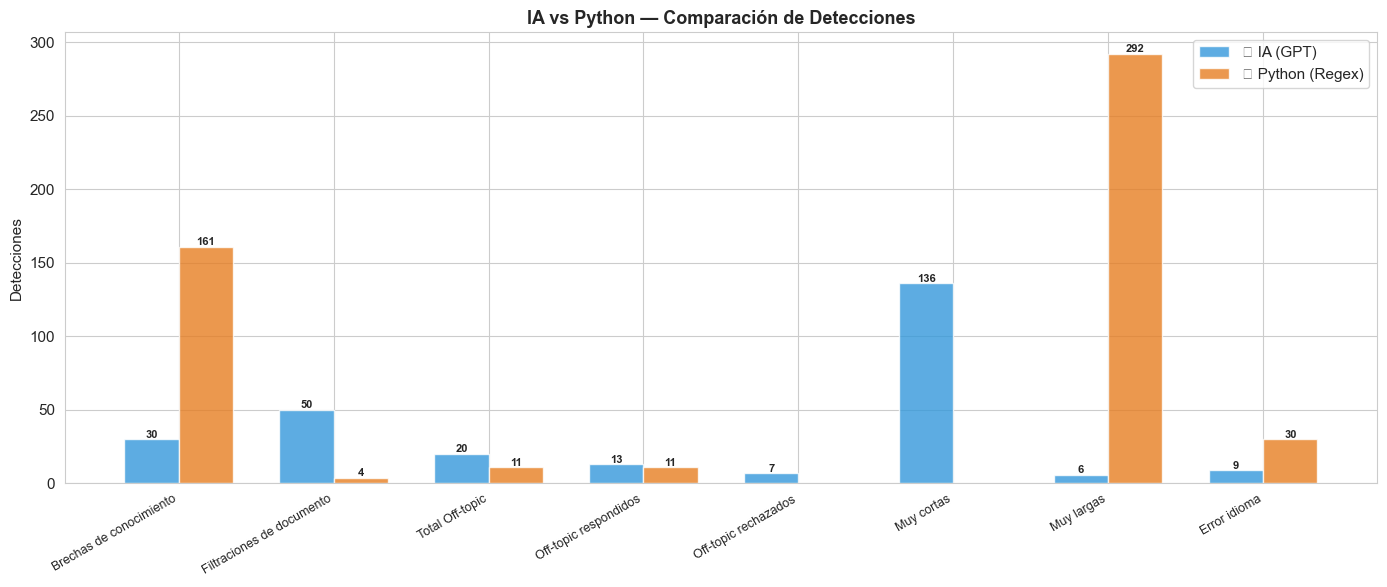

In [51]:
# === COMPARACIÓN IA vs PYTHON ===
pa = pattern_results

# AI metrics
ai_gaps = len(ai['knowledge_gaps'])
ai_leaks = len(ai['doc_leaks'])
ai_ot_total = len(ai['off_topic_questions'])
ai_ot_ans = ai['off_topic_answered']
ai_ot_ref = ai['off_topic_refused']
ai_generic = ai['issues'].get('too_generic', 0)
ai_short = ai['issues'].get('too_short', 0)
ai_long = ai['issues'].get('too_long', 0)
ai_lang = ai['issues'].get('language_mismatch', 0)

# Python metrics
py_gaps = len(pa['knowledge_gaps'])
py_leaks = len(pa['doc_leaks'])
py_ot_total = len(pa['off_topic'])
py_ot_ans = pa['off_topic_answered']
py_ot_ref = pa['off_topic_refused']
py_short = len([l for l in pa['length_issues'] if l['type'] == 'too_short'])
py_long = len([l for l in pa['length_issues'] if l['type'] == 'too_long'])
py_lang = len(pa['language_mismatches'])

comparison = [
    ('Brechas de conocimiento', ai_gaps, py_gaps),
    ('Filtraciones de documento', ai_leaks, py_leaks),
    ('Total Off-topic', ai_ot_total, py_ot_total),
    ('Off-topic respondidos', ai_ot_ans, py_ot_ans),
    ('Off-topic rechazados', ai_ot_ref, py_ot_ref),
    ('Genéricas / vagas', ai_generic, None),
    ('Muy cortas', ai_short, py_short),
    ('Muy largas', ai_long, py_long),
    ('Error idioma', ai_lang, py_lang),
]

# Table display
print("🔄 COMPARACIÓN: Análisis IA vs Análisis por Patrones (Python regex)")
print("="*70)
print(f"\n{'Métrica':<35} {'🧠 IA':>8} {'🐍 Python':>10} {'Diff':>8}")
print("-"*65)
for metric, ai_val, py_val in comparison:
    if py_val is not None:
        diff = ai_val - py_val
        diff_str = f'{diff:+d}' if diff != 0 else '='
    else:
        diff_str = '-'
    print(f"  {metric:<33} {ai_val:>8} {str(py_val if py_val is not None else '-'):>10} {diff_str:>8}")

print("\n💡 Diferencias son normales — la IA entiende contexto, el regex detecta frases exactas.")

# Visual comparison (only metrics with both values)
chart_data = [(m, a, p) for m, a, p in comparison if p is not None]
metrics_labels = [m for m, _, _ in chart_data]
ai_vals = [a for _, a, _ in chart_data]
py_vals = [p for _, _, p in chart_data]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metrics_labels))
width = 0.35
bars1 = ax.bar(x - width/2, ai_vals, width, label='🧠 IA (GPT)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, py_vals, width, label='🐍 Python (Regex)', color='#e67e22', alpha=0.8)

ax.set_ylabel('Detecciones')
ax.set_title('IA vs Python — Comparación de Detecciones', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, rotation=30, ha='right', fontsize=9)
ax.legend()

for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)), ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()